# Bussed Ramsey Paper Analysis

This notebook keeps the same downstream phase and amplitude analysis as
`Line_signal_compensation_bussed_ramsey.ipynb`, but changes the ingest stage:

1. Read all paper-data files from `Paper_data`.
2. Sort them by transition pair, `LT_comp`, and wait time.
3. Aggregate every repeated wait-time group by concatenating the raw shots.
4. Fit one sine curve to each aggregated wait-time group.

Assumption:
- Each paper-data `.txt` file stores raw-data filenames in the same last-line format as the
  existing line-signal notebook input files.
- `mean_dev_hz` is set manually because this dataset is not being sourced from the original log file.


In [37]:
import os
import re
import io
import ast
from datetime import datetime
from pathlib import Path
from collections import defaultdict

paper_data_dir = r"Z:\Lab Data\Qudit_Ramsey_raw_data\Bussed_ramsey_detuning_calibration_data\Paper_data"
raw_data_root = r"Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data_copied"

# Keep the same alias names the original notebook used.
directory_path = paper_data_dir
Z_drive_raw_data = raw_data_root

# Edit this transition pair before running the pipeline cell.
target_transitions = [[0, 3, 2], [0, 2, 0]]

# Assumption: unlike the original notebook, this data source does not provide a log-derived
# mean frequency deviation. Leave this at 0.0 unless you have an external value to fold into
# the phase uncertainties.
mean_dev_hz = 0.0


def parse_paper_filename(filename):
    pattern = (
        r"Ramsey_experiment_\[\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\],\s*"
        r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\]_"
        r"(\d+(?:\.\d+)?)_us_LT_comp_(True|False)_(\d{8})_(\d{4})\.txt$"
    )
    match = re.match(pattern, filename)
    if not match:
        return None

    transitions = (
        (int(match.group(1)), int(match.group(2)), int(match.group(3))),
        (int(match.group(4)), int(match.group(5)), int(match.group(6))),
    )
    wait_time_us = float(match.group(7))
    lt_comp = match.group(8) == "True"
    date_time = datetime.strptime(match.group(9) + match.group(10), "%Y%m%d%H%M")

    return {
        "transitions": transitions,
        "wait_time_us": wait_time_us,
        "LT_comp": lt_comp,
        "date_time": date_time,
    }


def parse_filename(filename):
    parsed = parse_paper_filename(filename)
    if parsed is None:
        return None, None, None, None
    return (
        parsed["transitions"],
        parsed["wait_time_us"],
        parsed["date_time"],
        parsed["LT_comp"],
    )


def normalize_raw_data_path(raw_name, raw_data_root):
    raw_name = str(raw_name).strip().strip("'\"")
    if not raw_name:
        return None

    raw_path = Path(raw_name)
    if raw_path.is_absolute():
        return str(raw_path)

    return str(Path(raw_data_root) / raw_name)


def extract_raw_data_filenames(file_path):
    with open(file_path, "r", encoding="utf-8", errors="replace") as file:
        lines = [line.strip() for line in file if line.strip()]
    if not lines:
        return []

    raw_data_filenames_line = lines[-1]
    try:
        parsed = ast.literal_eval(raw_data_filenames_line)
    except Exception:
        parsed = [
            name.strip().strip("'\"")
            for name in raw_data_filenames_line.strip("[]").split(",")
            if name.strip()
        ]

    if isinstance(parsed, (list, tuple)):
        return [str(item).strip() for item in parsed if str(item).strip()]

    return [str(parsed).strip()]


def build_paper_data_index(directory, raw_data_root):
    index = defaultdict(lambda: {False: defaultdict(dict), True: defaultdict(dict)})

    for filename in sorted(os.listdir(directory)):
        if not filename.startswith("Ramsey_experiment"):
            continue

        parsed = parse_paper_filename(filename)
        if parsed is None:
            continue

        file_path = os.path.join(directory, filename)
        raw_data_filenames = extract_raw_data_filenames(file_path)
        raw_data_filepaths = []
        for raw_name in raw_data_filenames:
            normalized = normalize_raw_data_path(raw_name, raw_data_root)
            if normalized is not None:
                raw_data_filepaths.append(normalized)

        transitions = parsed["transitions"]
        lt_comp = parsed["LT_comp"]
        wait_time_us = parsed["wait_time_us"]

        group = index[transitions][lt_comp].setdefault(
            wait_time_us,
            {
                "paper_files": [],
                "raw_data_filepaths": [],
                "timestamps": [],
            },
        )
        group["paper_files"].append(file_path)
        group["raw_data_filepaths"].extend(raw_data_filepaths)
        group["timestamps"].append(parsed["date_time"])

    return index


def summarize_paper_index(index):
    rows = []
    for transitions in sorted(index.keys(), key=str):
        for lt_comp in [False, True]:
            wait_groups = index[transitions][lt_comp]
            if not wait_groups:
                continue
            rows.append(
                {
                    "transitions": [list(t) for t in transitions],
                    "LT_comp": lt_comp,
                    "n_wait_times": len(wait_groups),
                    "n_paper_files": sum(len(group["paper_files"]) for group in wait_groups.values()),
                    "min_wait_us": min(wait_groups.keys()),
                    "max_wait_us": max(wait_groups.keys()),
                }
            )
    return rows


def print_paper_index_summary(index):
    summary_rows = summarize_paper_index(index)
    if not summary_rows:
        print("No Ramsey paper-data files were found.")
        return

    print(f"Found {len(summary_rows)} transition/LT_comp groups in {paper_data_dir}")
    for row in summary_rows:
        print(
            f"Transitions={row['transitions']}, LT_comp={row['LT_comp']}, "
            f"wait groups={row['n_wait_times']}, paper files={row['n_paper_files']}, "
            f"wait range=[{row['min_wait_us']}, {row['max_wait_us']}] us"
        )


def get_grouped_wait_data(index, target_transitions, LT_comp):
    tkey = tuple(tuple(t) for t in target_transitions)
    if tkey not in index:
        raise ValueError(f"Target transitions {target_transitions} are not present in the paper-data folder.")

    wait_groups = index[tkey][bool(LT_comp)]
    if not wait_groups:
        raise ValueError(
            f"No files found for transitions {target_transitions} with LT_comp={bool(LT_comp)}."
        )

    wait_times = sorted(wait_groups.keys())
    raw_file_paths_list = [wait_groups[wt]["raw_data_filepaths"] for wt in wait_times]

    return wait_times, raw_file_paths_list, wait_groups


def expand_grouped_wait_data_to_individual_scans(wait_groups):
    wait_time_list = []
    raw_file_paths_list = []
    paper_file_list = []

    for wt in sorted(wait_groups.keys()):
        group = wait_groups[wt]
        zipped = zip(group["timestamps"], group["paper_files"])
        for _, paper_file in sorted(zipped, key=lambda item: item[0]):
            raw_data_filenames = extract_raw_data_filenames(paper_file)
            raw_paths = []
            for raw_name in raw_data_filenames:
                normalized = normalize_raw_data_path(raw_name, raw_data_root)
                if normalized is not None:
                    raw_paths.append(normalized)
            wait_time_list.append(float(wt))
            raw_file_paths_list.append(raw_paths)
            paper_file_list.append(paper_file)

    return wait_time_list, raw_file_paths_list, paper_file_list

paper_index = build_paper_data_index(paper_data_dir, raw_data_root)
print_paper_index_summary(paper_index)


Found 2 transition/LT_comp groups in Z:\Lab Data\Qudit_Ramsey_raw_data\Bussed_ramsey_detuning_calibration_data\Paper_data
Transitions=[[0, 3, 2], [0, 2, 0]], LT_comp=False, wait groups=21, paper files=108, wait range=[0.0, 4000.0] us
Transitions=[[0, 3, 2], [0, 2, 0]], LT_comp=True, wait groups=21, paper files=93, wait range=[0.0, 4000.0] us


## Raw data processing


In [38]:
import numpy as np
import json

# --------------------------------
# Existing Functions (Unchanged)
# --------------------------------

def getShelvingThreshold(counts):
    data_sorted = np.sort(counts, axis=None)
    # print("Total sorted data points:", len(data_sorted))
    # Remove extreme ends (if possible)
    if len(data_sorted) > 4000:
        data_sorted = data_sorted[2000:-2000]
    if len(data_sorted) > 2000:
        step = round(data_sorted.size / (len(counts) * 0.0250167))
        if step < 1:
            step = 1
        data_sorted = data_sorted[0:-1:step]
    data_sorted_diff = data_sorted[1:-1] - data_sorted[0:-2]
    data_diff_max = max(data_sorted_diff)
    data_diff_maxind = np.argmax(data_sorted_diff)
    threshold = data_diff_max / 2 + data_sorted[data_diff_maxind]
    
    # New logic: if the calculated threshold is less than 2, recalculate using histogram data.
    # if threshold < 2:
        # Calculate histogram in the x-range 4 to 30
    hist_counts, bin_edges = np.histogram(counts, bins=range(4, 31))
    # Find the bin (lowest bar) with the minimum count in that range
    min_bin_index = np.argmin(hist_counts)
    # Use the lower edge of that bin as the threshold
    threshold = bin_edges[min_bin_index] + 0.5

    if threshold < 2 or threshold > 20:
        threshold = 11

    print(f"Threshold recalculated using histogram: {threshold}")
    
    return threshold, data_sorted

def process_raw_data_files(raw_data_filepaths, ket_1_first):
    arrays = []
    # Read and process the data from all raw data files
    # print(raw_data_filepaths)
    for file_path in raw_data_filepaths:
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"])
    # Convert to numpy array
    hist_data = np.array(arrays)
    
    # Flatten the hist_data and compute shelving threshold
    flat_hist_data = hist_data.flatten()
    threshold, _ = getShelvingThreshold(flat_hist_data)

    # Prepare for further processing (3D array)
    arrays_3d = []
    for file_path in raw_data_filepaths[:]:
        arrays = []
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"][:])
        if len(arrays) == 0:
            arrays = list(np.full((100, 3), 40))  # fallback if no data
        arrays_3d.append(arrays)

    bool_array = np.array(arrays_3d) > threshold
    print(bool_array.shape)
    print(threshold)
    result_matrix = np.full(bool_array.shape, False, dtype=bool)
    # Identify the first occurrence of shelving (True value)
    if bool_array.shape[2] < 3:
        result_matrix = np.full(bool_array.shape + np.array([0,0,1]), False, dtype=bool)
        print("Warning: Expected at least 3 columns in the data for shelving detection.")
        for matrix_index in range(bool_array.shape[0]):
            for row_index in range(bool_array.shape[1]):
                true_indices = np.where(bool_array[matrix_index, row_index, :])
                data_bool = bool_array[matrix_index, row_index, :]
                if data_bool[0] == False:
                    if data_bool[1] == True:
                        result_matrix[matrix_index, row_index, 1] = True
                    if data_bool[1] == False:
                        result_matrix[matrix_index, row_index, 2] = True
    else:
        for matrix_index in range(bool_array.shape[0]):
            for row_index in range(bool_array.shape[1]):
                true_indices = np.where(bool_array[matrix_index, row_index, :])
                data_bool = bool_array[matrix_index, row_index, :]
                if data_bool[0] == False:
                    if data_bool[1] == True:
                        result_matrix[matrix_index, row_index, 1] = True
                    if data_bool[1] == False:
                        result_matrix[matrix_index, row_index, 2] = True

    # Filter data and compute percentages used
    filtered_data_array = []
    percentage_data_used = []
    num_points = bool_array.shape[0]  # Determine the number of data points
    for i in range(num_points):
        data = result_matrix[i]
        rows_with_any_true = data.any(axis=1)
        filtered_data = data[rows_with_any_true]
        filtered_data_array.append(filtered_data)
        percentage_data_used.append(filtered_data.shape[0] / data.shape[0])

    # Compute ket data by averaging the filtered data
    def find_errors(num_SD, full_data_array, exp_num):
        upper_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) + np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        lower_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) - np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        return lower_error, upper_error

    ket_data = []
    exp_num_list = []
    for filtered_data in filtered_data_array:
        # if ket_1_first:
        #     ket_data.append(np.mean(filtered_data, axis=0)[2])
        # else:
        ket_data.append(np.mean(filtered_data, axis=0)[1])
        exp_num_list.append(len(filtered_data))
    print(exp_num_list)
    lower_error, upper_error = find_errors(1, np.array(ket_data), np.array(exp_num_list))
    
    return ket_data, lower_error, upper_error


# ------------------------------------------------
# New Function Using Parallel Lists (NOT a dict)
# ------------------------------------------------
def process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list, ket_1_first = False):
    processed_wait_times = []
    ket_data_list = []
    lower_error_list = []
    upper_error_list = []
    
    for i, wait_time in enumerate(wait_time_list):
        raw_data_filepaths = raw_file_paths_list[i]
        print('-------------------------------------------------------------------------')
        print('Wait time:', wait_time, 'Processing files:', raw_data_filepaths[0])
        ket_data, lower_error, upper_error = process_raw_data_files(raw_data_filepaths, ket_1_first)

        processed_wait_times.append(wait_time)

        ket_data_arr = np.array(ket_data)
        final_lower_error = np.abs(ket_data_arr - np.array(lower_error))
        final_upper_error = np.abs(np.array(upper_error) - ket_data_arr)

        ket_data_list.append(ket_data)
        lower_error_list.append(final_lower_error)
        upper_error_list.append(final_upper_error)

    return processed_wait_times, ket_data_list, lower_error_list, upper_error_list


LT_comp = True  # Change to True to inspect the compensated scans in the step-by-step cells.
ket_1_first = target_transitions[0][1:] == target_transitions[1][1:]

grouped_wait_times, grouped_raw_file_paths_list, wait_groups = get_grouped_wait_data(
    paper_index, target_transitions, LT_comp
)

if len(grouped_wait_times) == 0:
    raise ValueError("No grouped wait times found for the selected transition/LT_comp.")

wait_time_list, raw_file_paths_list, paper_file_list = expand_grouped_wait_data_to_individual_scans(wait_groups)

if len(wait_time_list) == 0:
    raise ValueError("No individual paper-data scans were found for the selected transition/LT_comp.")

wait_time_list, raw_file_paths_list, paper_file_list = zip(
    *sorted(zip(wait_time_list, raw_file_paths_list, paper_file_list), key=lambda x: (x[0], x[2]))
)

wait_time_list = list(wait_time_list)
raw_file_paths_list = list(raw_file_paths_list)
paper_file_list = list(paper_file_list)

(
    processed_wait_times,
    ket_data_list,
    lower_error_list,
    upper_error_list
) = process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list, ket_1_first=ket_1_first)

print("\\nProcessed individual scans (duplicates in wait time are expected here):")
for paper_file, wt, ket_vals, le_vals, ue_vals in zip(
    paper_file_list, processed_wait_times, ket_data_list, lower_error_list, upper_error_list
):
    print(f"\\nPaper file: {os.path.basename(paper_file)}")
    print(f"Wait Time: {wt} us")
    print(f"Ket Data (list): {ket_vals}")
    print(f"Lower Error (array): {le_vals}")
    print(f"Upper Error (array): {ue_vals}")


-------------------------------------------------------------------------
Wait time: 0.0 Processing files: Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data_copied\2026\2026_04\2026_04_27\qudit_ramsey_scan_bused_1003
Threshold recalculated using histogram: 11.5
(6, 100, 2)
11.5
[97, 91, 99, 98, 97, 96]
-------------------------------------------------------------------------
Wait time: 0.0 Processing files: Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data_copied\2026\2026_04\2026_04_27\qudit_ramsey_scan_bused_1656
Threshold recalculated using histogram: 10.5
(6, 100, 2)
10.5
[97, 99, 98, 95, 98, 97]
-------------------------------------------------------------------------
Wait time: 0.0 Processing files: Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data_copied\2026\2026_04\2026_04_27\qudit_ramsey_scan_bused_2274
Threshold recalculated using histogram: 9.5
(6, 100, 2)
9.5
[99, 98, 98, 99, 98, 99]
-------------------------------------------------------------------------
Wait time: 0.0 Processing files: Z:\L

## Sine fitting on aggregated wait-time groups


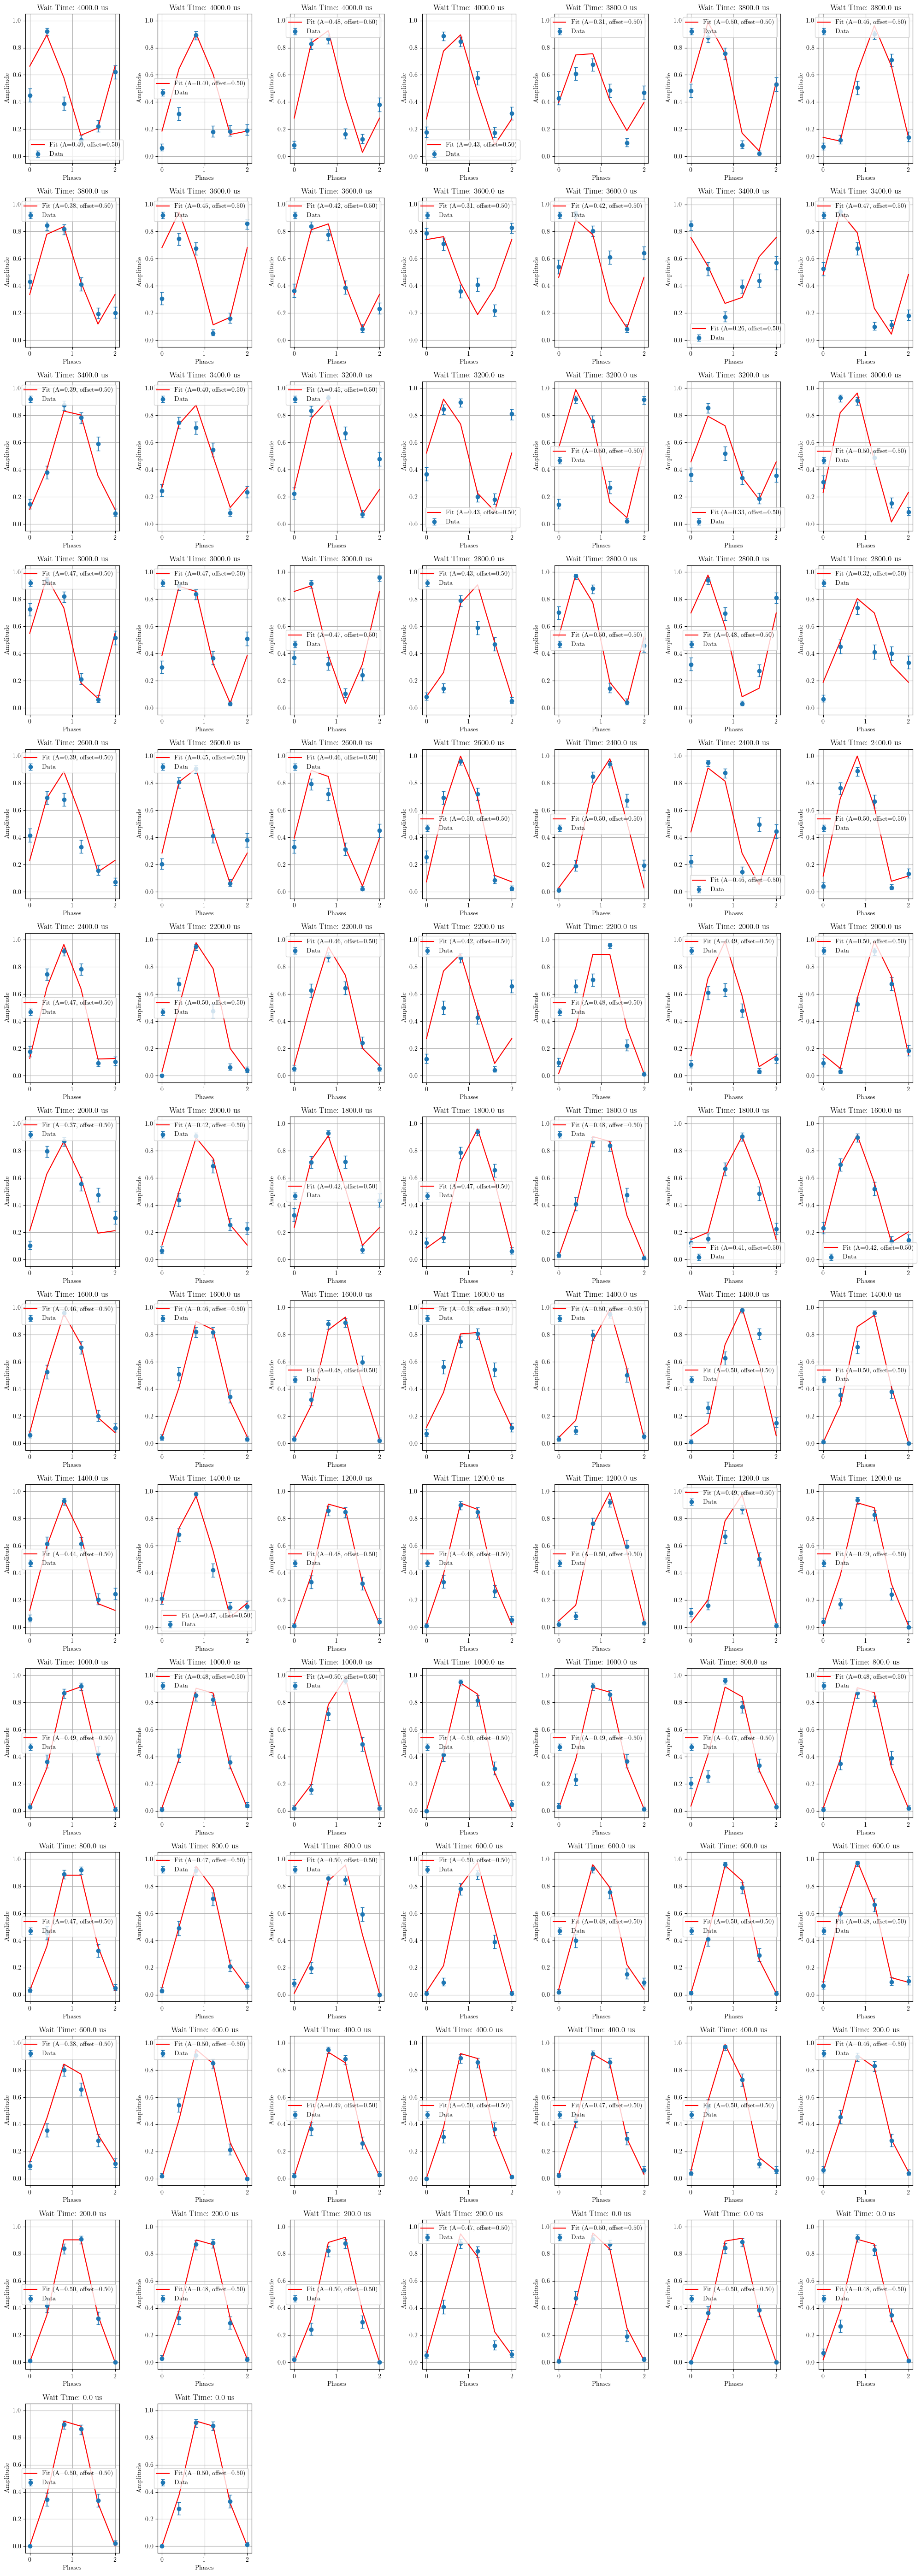


Fitted Results (individual paper-data scans):
Wait Time: 0.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.499, 6.220
  Amplitude (2*|A|) = 0.998 +/- 0.010
  Phase = 6.220 +/- 0.051
Wait Time: 0.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.498, 6.220
  Amplitude (2*|A|) = 0.996 +/- 0.010
  Phase = 6.220 +/- 0.053
Wait Time: 0.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.482, 6.220
  Amplitude (2*|A|) = 0.963 +/- 0.019
  Phase = 6.220 +/- 0.053
Wait Time: 0.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.500, 0.036
  Amplitude (2*|A|) = 0.999 +/- 0.007
  Phase = 0.036 +/- 0.054
Wait Time: 0.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.496, 6.079
  Amplitude (2*|A|) = 0.992 +/- 0.019
  Phase = 6.079 +/- 0.049
Wait Time: 200.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.470, 5.972
  Amplitude (2*|A|) = 0.939 +/- 0.030
  Phase = 5.972 +/- 0.051
Wait Time: 200.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.498, 0.065
  Amplitude (2*|A|)

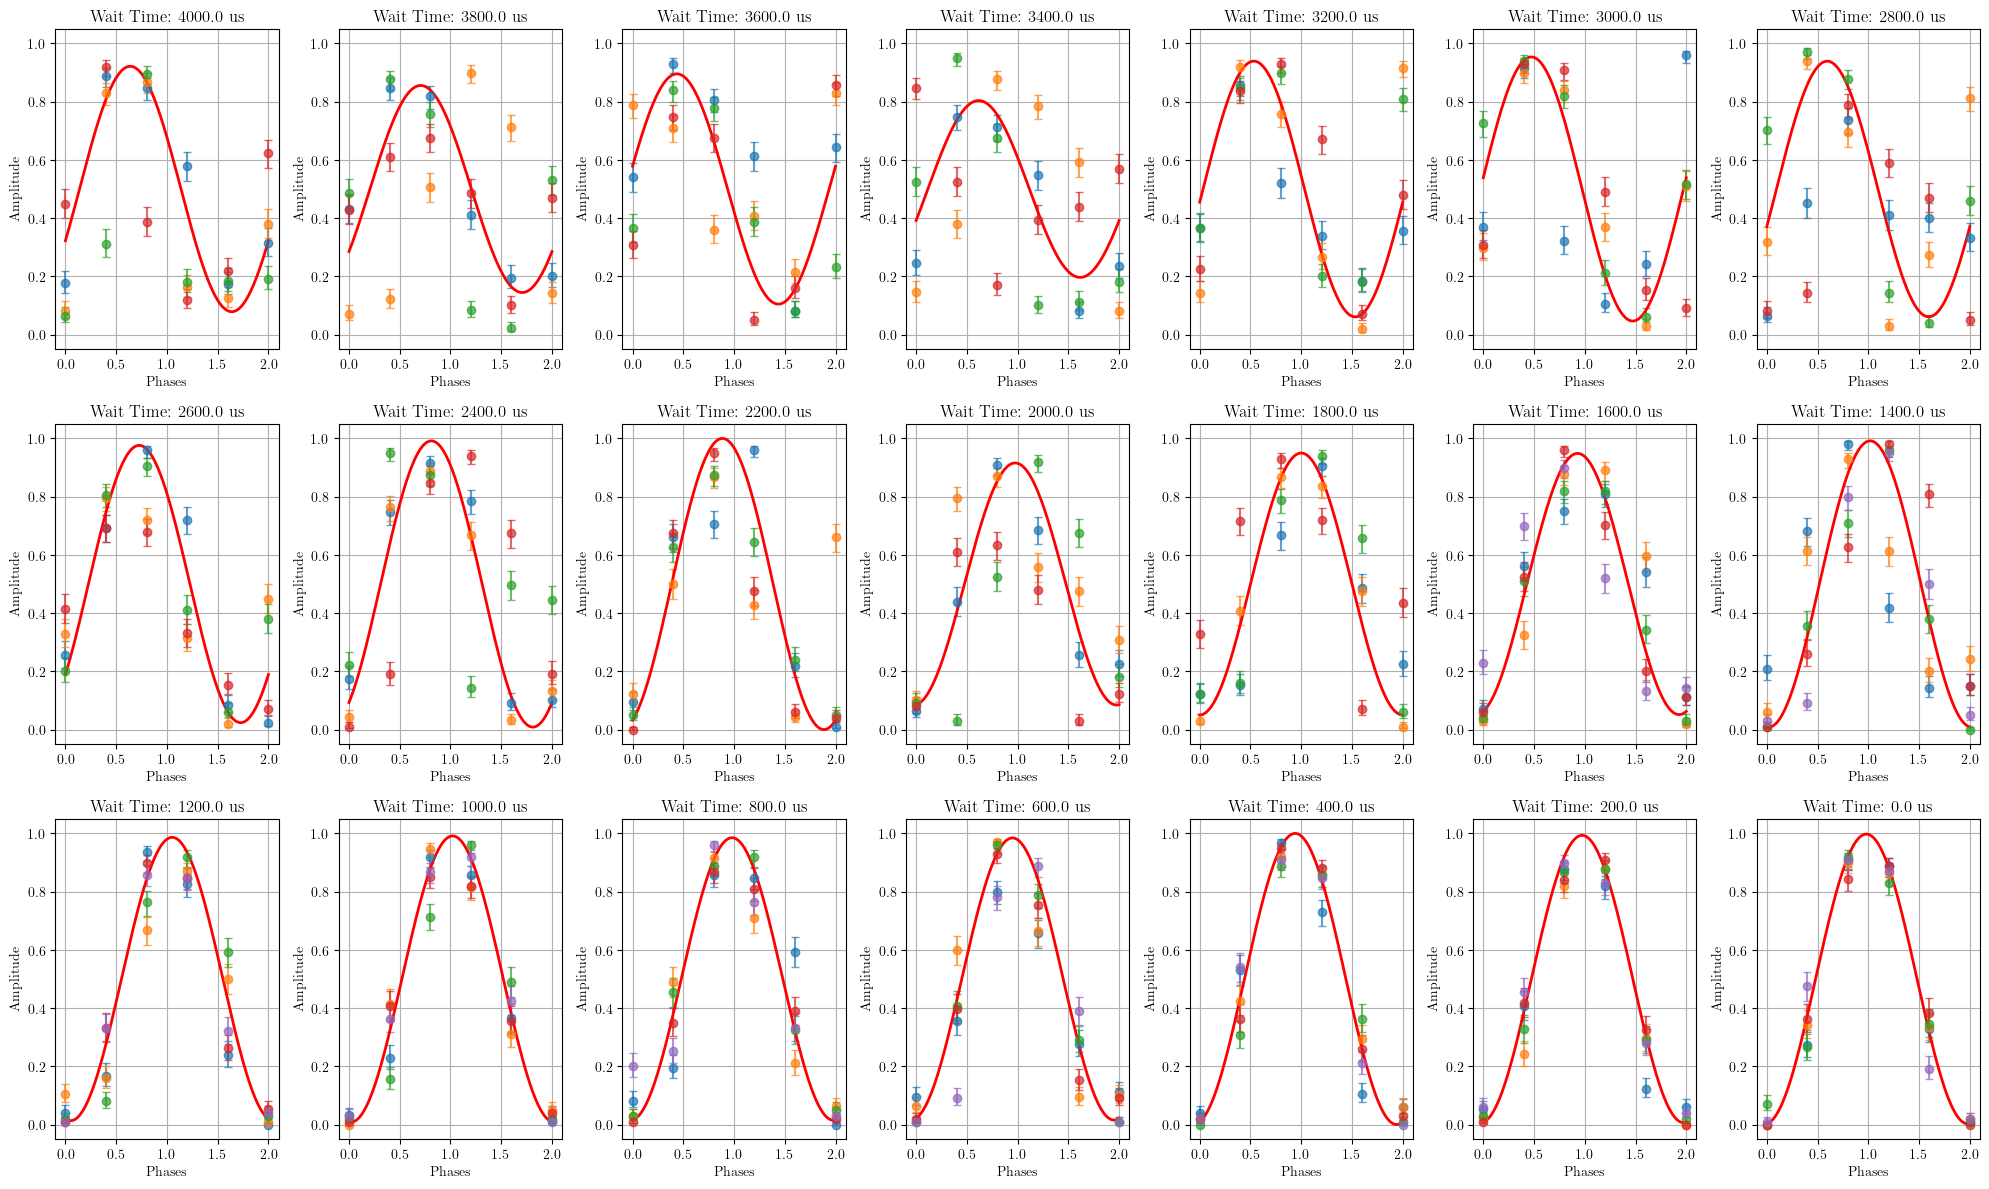


Fitted Results: grouped by wait time
Wait Time: 0.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.498, 6.220
  Amplitude (2*|A|) = 0.995 +/- 0.005
  Phase = 6.220 +/- 0.023
Wait Time: 200.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.493, 6.200
  Amplitude (2*|A|) = 0.987 +/- 0.006
  Phase = 6.200 +/- 0.023
Wait Time: 400.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.500, 6.096
  Amplitude (2*|A|) = 1.000 +/- 0.007
  Phase = 6.096 +/- 0.021
Wait Time: 600.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.484, 6.123
  Amplitude (2*|A|) = 0.969 +/- 0.009
  Phase = 6.123 +/- 0.022
Wait Time: 800.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.485, 6.220
  Amplitude (2*|A|) = 0.970 +/- 0.008
  Phase = 6.220 +/- 0.024
Wait Time: 1000.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.491, 0.066
  Amplitude (2*|A|) = 0.983 +/- 0.007
  Phase = 0.066 +/- 0.023
Wait Time: 1200.0 us
  Params (A, phi) with offset fixed at 0.500 = 0.487, 0.163
  Amplitude (2*|A|

In [39]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

FIT_OFFSET = 0.5


def sine_function(t, A, phi, offset=FIT_OFFSET):
    return A * np.cos(2 * np.pi / 10 * t - phi - np.pi) + offset


def _fit_fixed_offset_model(t_valid, ket_data_valid, sigma):
    A0 = (np.max(ket_data_valid) - np.min(ket_data_valid)) / 2
    A0 = np.clip(A0, 0.0, 0.5)
    initial_guess = [A0 if np.isfinite(A0) else 0.44, np.pi]

    try:
        raw_params, covariance = curve_fit(
            lambda t, A, phi: sine_function(t, A, phi, FIT_OFFSET),
            t_valid,
            ket_data_valid,
            p0=initial_guess,
            sigma=sigma,
            absolute_sigma=True,
            maxfev=10000,
            bounds=([0.0, 0.0], [0.5, 2 * np.pi * 0.99]),
        )
        params = [raw_params[0], raw_params[1], FIT_OFFSET]
        if covariance is not None:
            raw_errors = np.sqrt(np.diag(covariance))
            errors = [
                raw_errors[0] if np.isfinite(raw_errors[0]) else None,
                raw_errors[1] if np.isfinite(raw_errors[1]) else None,
                0.0,
            ]
        else:
            errors = [None, None, 0.0]
        return params, errors
    except RuntimeError:
        return None, None


def fit_sine_curve(ket_data, lower_error, upper_error):
    t = np.linspace(0, 10, len(ket_data))
    valid_indices = ~np.isnan(ket_data) & ~np.isnan(lower_error) & ~np.isnan(upper_error)
    t_valid = t[valid_indices]
    ket_data_valid = np.array(ket_data)[valid_indices]
    lower_error_valid = np.array(lower_error)[valid_indices]
    upper_error_valid = np.array(upper_error)[valid_indices]

    sigma = (upper_error_valid + lower_error_valid) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    return _fit_fixed_offset_model(t_valid, ket_data_valid, sigma)


def fit_all_wait_times_to_sine_in_lists(wait_time_list,
                                        ket_data_list,
                                        lower_error_list,
                                        upper_error_list):
    fit_wait_times_list = []
    fit_params_list = []
    fit_amplitudes_list = []
    fit_amplitude_errors_list = []
    fit_phases_list = []
    fit_phase_errors_list = []

    for i in range(len(wait_time_list)):
        wt = wait_time_list[i]
        kd = ket_data_list[i]
        le = lower_error_list[i]
        ue = upper_error_list[i]

        if len(kd) > 4:
            params, errors = fit_sine_curve(kd, le, ue)
            if params is not None and errors is not None and errors[0] is not None:
                A, phi, offset = params
                amplitude = 2.0 * abs(A)
                amplitude_error = 2.0 * errors[0] if errors[0] is not None else None
                phase_error = errors[1]

                fit_wait_times_list.append(wt)
                fit_params_list.append(params)
                fit_amplitudes_list.append(amplitude)
                fit_amplitude_errors_list.append(amplitude_error)
                fit_phases_list.append(phi)
                fit_phase_errors_list.append(phase_error)
        else:
            fit_wait_times_list.append(wt)
            fit_params_list.append([None, None, FIT_OFFSET])
            fit_amplitudes_list.append(None)
            fit_amplitude_errors_list.append(None)
            fit_phases_list.append(None)
            fit_phase_errors_list.append(None)
    return (
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list
    )


def plot_sine_fits_in_lists(wait_time_list,
                            ket_data_list,
                            lower_error_list,
                            upper_error_list,
                            fit_wait_times_list,
                            fit_params_list):
    num_plots = len(wait_time_list)
    num_columns = 7
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    reversed_fit_params = fit_params_list[::-1]

    for i in range(num_plots):
        wt = wait_time_list[::-1][i]
        kd = ket_data_list[::-1][i]
        le = lower_error_list[::-1][i]
        ue = upper_error_list[::-1][i]

        t = np.linspace(0, 10, len(kd))
        ax = axes[i]
        ax.errorbar(
            np.array(t) * 2 / 10,
            kd,
            yerr=[abs(le), abs(ue)],
            fmt='o',
            label='Data',
            capsize=3
        )

        A, phi, offset = reversed_fit_params[i]
        if A is not None:
            fit_curve = sine_function(t, A, phi, offset)
            ax.plot(
                np.array(t) * 2 / 10,
                fit_curve,
                color='red',
                label=f'Fit (A={A:.2f}, offset={offset:.2f})'
            )

        ax.set_title(f'Wait Time: {wt} us')
        ax.set_xlabel('Phases')
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel('Amplitude')
        ax.grid()
        ax.legend()

    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.savefig('bussed_ramsey_raw_phase_scans.pdf')
    plt.show()


def fit_sine_curve_combined(kd_group, le_group, ue_group):
    """
    Fit all scans with the same wait time together using a fixed offset.
    kd_group, le_group, ue_group are lists of arrays.
    """

    all_t = []
    all_kd = []
    all_sigma = []

    for kd, le, ue in zip(kd_group, le_group, ue_group):
        kd = np.array(kd)
        le = np.array(le)
        ue = np.array(ue)

        t = np.linspace(0, 10, len(kd))

        valid_indices = ~np.isnan(kd) & ~np.isnan(le) & ~np.isnan(ue)

        kd_valid = kd[valid_indices]
        le_valid = le[valid_indices]
        ue_valid = ue[valid_indices]
        t_valid = t[valid_indices]

        sigma = (np.abs(le_valid) + np.abs(ue_valid)) / 2.0

        if np.any(sigma <= 0):
            nonzero = sigma[sigma > 0]
            replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
            sigma[sigma <= 0] = replacement

        all_t.append(t_valid)
        all_kd.append(kd_valid)
        all_sigma.append(sigma)

    all_t = np.concatenate(all_t)
    all_kd = np.concatenate(all_kd)
    all_sigma = np.concatenate(all_sigma)

    return _fit_fixed_offset_model(all_t, all_kd, all_sigma)


def fit_grouped_wait_times(wait_time_list,
                           ket_data_list,
                           lower_error_list,
                           upper_error_list):

    grouped_data = defaultdict(lambda: {"kd": [], "le": [], "ue": []})

    for wt, kd, le, ue in zip(
        wait_time_list,
        ket_data_list,
        lower_error_list,
        upper_error_list
    ):
        grouped_data[wt]["kd"].append(kd)
        grouped_data[wt]["le"].append(le)
        grouped_data[wt]["ue"].append(ue)

    fit_wait_times_list = []
    fit_params_list = []
    fit_amplitudes_list = []
    fit_amplitude_errors_list = []
    fit_phases_list = []
    fit_phase_errors_list = []

    for wt in sorted(grouped_data.keys()):
        kd_group = grouped_data[wt]["kd"]
        le_group = grouped_data[wt]["le"]
        ue_group = grouped_data[wt]["ue"]

        total_points = sum(len(kd) for kd in kd_group)

        if total_points > 4:
            params, errors = fit_sine_curve_combined(kd_group, le_group, ue_group)

            if params is not None and errors is not None:
                A, phi, offset = params

                fit_wait_times_list.append(wt)
                fit_params_list.append(params)
                fit_amplitudes_list.append(2.0 * abs(A))
                fit_amplitude_errors_list.append(2.0 * errors[0])
                fit_phases_list.append(phi)
                fit_phase_errors_list.append(errors[1])
            else:
                fit_wait_times_list.append(wt)
                fit_params_list.append([None, None, FIT_OFFSET])
                fit_amplitudes_list.append(None)
                fit_amplitude_errors_list.append(None)
                fit_phases_list.append(None)
                fit_phase_errors_list.append(None)

    return (
        grouped_data,
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list
    )


def plot_grouped_sine_fits(grouped_data,
                           fit_wait_times_list,
                           fit_params_list):

    unique_wait_times = sorted(grouped_data.keys())[::-1]

    num_plots = len(unique_wait_times)
    num_columns = 7
    num_rows = (num_plots + num_columns - 1) // num_columns

    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    fit_dict = {
        wt: params
        for wt, params in zip(fit_wait_times_list, fit_params_list)
    }

    for i, wt in enumerate(unique_wait_times):
        ax = axes[i]

        kd_group = grouped_data[wt]["kd"]
        le_group = grouped_data[wt]["le"]
        ue_group = grouped_data[wt]["ue"]

        for scan_index, (kd, le, ue) in enumerate(zip(kd_group, le_group, ue_group)):
            kd = np.array(kd)
            le = np.array(le)
            ue = np.array(ue)

            t = np.linspace(0, 10, len(kd))
            phase_axis = t * 2 / 10

            ax.errorbar(
                phase_axis,
                kd,
                yerr=[np.abs(le), np.abs(ue)],
                fmt='o',
                capsize=3,
                alpha=0.7,
                label=f'Data {scan_index + 1}'
            )

        if wt in fit_dict:
            A, phi, offset = fit_dict[wt]

            if A is not None:
                t_fit = np.linspace(0, 10, 500)
                phase_fit = t_fit * 2 / 10
                fit_curve = sine_function(t_fit, A, phi, offset)

                ax.plot(
                    phase_fit,
                    fit_curve,
                    color='red',
                    linewidth=2,
                    label=f'Combined fit, A={A:.2f}, offset={offset:.2f}'
                )

        ax.set_title(f'Wait Time: {wt} us')
        ax.set_xlabel('Phases')
        ax.set_ylabel('Amplitude')
        ax.set_ylim(-0.05, 1.05)
        ax.grid()

    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.savefig('bussed_ramsey_grouped_phase_scans.pdf')
    plt.show()


individual_wait_time_list_for_fit = processed_wait_times

(
    individual_fit_wait_times_list,
    individual_fit_params_list,
    individual_fit_amplitudes_list,
    individual_fit_amplitude_errors_list,
    individual_fit_phases_list,
    individual_fit_phase_errors_list
) = fit_all_wait_times_to_sine_in_lists(
    individual_wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list
)

plot_sine_fits_in_lists(
    individual_wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    individual_fit_wait_times_list,
    individual_fit_params_list
)

print("\nFitted Results (individual paper-data scans):")
for i, wt in enumerate(individual_fit_wait_times_list):
    A, phi, offset = individual_fit_params_list[i]
    amp = individual_fit_amplitudes_list[i]
    amp_err = individual_fit_amplitude_errors_list[i]
    phase = individual_fit_phases_list[i]
    phase_err = individual_fit_phase_errors_list[i]

    print(f"Wait Time: {wt} us")
    if A is None:
        print("  Fit failed")
    else:
        print(f"  Params (A, phi) with offset fixed at {offset:.3f} = {A:.3f}, {phi:.3f}")
        print(f"  Amplitude (2*|A|) = {amp:.3f} +/- {amp_err:.3f}")
        print(f"  Phase = {phase:.3f} +/- {phase_err:.3f}")


(
    grouped_data,
    fit_wait_times_list,
    fit_params_list,
    fit_amplitudes_list,
    fit_amplitude_errors_list,
    fit_phases_list,
    fit_phase_errors_list
) = fit_grouped_wait_times(
    individual_wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list
)

plot_grouped_sine_fits(
    grouped_data,
    fit_wait_times_list,
    fit_params_list
)

print("\nFitted Results: grouped by wait time")
for i, wt in enumerate(fit_wait_times_list):
    A, phi, offset = fit_params_list[i]
    amp = fit_amplitudes_list[i]
    amp_err = fit_amplitude_errors_list[i]
    phase = fit_phases_list[i]
    phase_err = fit_phase_errors_list[i]

    print(f"Wait Time: {wt} us")

    if A is None:
        print("  Fit failed")
    else:
        print(f"  Params (A, phi) with offset fixed at {offset:.3f} = {A:.3f}, {phi:.3f}")
        print(f"  Amplitude (2*|A|) = {amp:.3f} +/- {amp_err:.3f}")
        print(f"  Phase = {phase:.3f} +/- {phase_err:.3f}")


## Theory model from the original notebook


In [40]:

def compute_phases_from_line_fit(
    pulse_train,
    fractions,
    pi_t=(23.76, 36.54, 106.33, 32.755, 39.168),
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file=r"Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt",
    t_ref="start",  # "mid", "start", or "end"
    transition_strengths_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p209.txt",
    sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p2079.txt",
    integral_scale=1.1, 
    LT_comp = False

):
    """
    Single-function version of your entire pipeline.

    Computes per-pulse phase corrections using:
        A(t) = t*B(t) - ∫_0^t B(t') dt'
    with B(t) = B_rel_G(t) (Gauss), so A(t) is in G*s.

    Phase per pulse i:
        phi_i = 2π * 1e6 * sens_i * A(t_i)

    Returns:
        phases_per_pulse (list[float]): same length as pulse_train
    """

    # -----------------------------
    # Helpers (nested)
    # -----------------------------
    def load_line_fit_parameters(filename):
        B0_fit = None
        B0_err = None
        harmonic_lines = []
        with open(filename, "r") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                if B0_fit is None:
                    vals = np.fromstring(stripped, sep=" ")
                    B0_fit, B0_err = vals[0], vals[1]
                else:
                    harmonic_lines.append(stripped)
        harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
        if harmonics.ndim == 1:
            harmonics = harmonics[None, :]
        freqs = harmonics[:, 0]
        A_vals = harmonics[:, 1]
        A_errs = harmonics[:, 2]
        phi_vals = harmonics[:, 3]
        phi_errs = harmonics[:, 4]
        return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

    def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
        if param_file is not None:
            B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
            return B0_fit, freqs, A_vals, phi_vals
        freqs = np.array([60.0, 180.0], dtype=float)
        A_vals = np.array([A60, A180], dtype=float)
        phi_vals = np.array([phi60, phi180], dtype=float)
        return B0, freqs, A_vals, phi_vals

    def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        y = np.full_like(t_arr, B0_use, dtype=float)
        for f, A, phi in zip(freqs, A_vals, phi_vals):
            y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
        return y

    def B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        return (
            B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=param_file)
            - B_line_mG(0.0, B0, A60, phi60, A180, phi180, param_file=param_file)
        ) * 1e-3

    def primitive_B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        t_arr_1d = np.atleast_1d(t_arr)
        omega = 2.0 * np.pi * freqs

        B_line_0 = B0_use + np.sum(A_vals * np.cos(phi_vals))
        const_term = (B0_use - B_line_0) * t_arr_1d
        sin_terms = (A_vals / omega)[:, None] * np.sin(omega[:, None] * t_arr_1d[None, :] + phi_vals[:, None])

        F_mG = const_term + np.sum(sin_terms, axis=0)
        F_Gs = 1e-3 * F_mG
        if np.isscalar(t):
            return float(F_Gs[0])
        return F_Gs

    def integral_B_rel_G(t_start, t_end, B0, A60, phi60, A180, phi180, param_file):
        F_end = primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180, param_file=param_file)
        F_start = primitive_B_rel_G(t_start, B0, A60, phi60, A180, phi180, param_file=param_file)
        return F_end - F_start

    def compute_pi_times(pi_t):
        transition_strengths = np.loadtxt(transition_strengths_path, delimiter=",")
        transition_strengths[transition_strengths == 0] = np.nan
        strengths = np.array(
            [
                transition_strengths[22, 1],
                transition_strengths[14, 0],
                transition_strengths[5, 2],
                transition_strengths[16, 4],
                transition_strengths[15, 4],
            ]
        )
        factors = np.array(pi_t, dtype=float) * strengths

        Fs = [1, 2, 3, 4]
        row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
        col_labels = [-2, -1, 0, 1, 2]

        pi_times = np.zeros((24, 5), dtype=float)
        for i in range(transition_strengths.shape[0]):
            for j in range(transition_strengths.shape[1]):
                if not np.isnan(transition_strengths[i, j]):
                    delta_m = (row_labels[i][1] - col_labels[j]) + 2
                    pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
        return pi_times

    def get_pi_times_from_matrix(transitions, matrix):
        Fs = [1, 2, 3, 4]
        states = []
        for i in Fs:
            for j in range(2 * i + 1):
                mF = i - j
                states.append([i, mF])
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]

        out = []
        for transition in transitions:
            row_label = [transition[1], transition[2]]
            col_label = transition[0]
            row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
            col_index = col_labels.index(col_label) if col_label in col_labels else None
            if row_index is not None and col_index is not None:
                out.append(matrix[row_index, col_index])
            else:
                out.append(np.nan)
        return out

    def get_pulse_schedule(rabi_freqs, fractions):
        if len(rabi_freqs) != len(fractions):
            raise ValueError(
                f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length."
            )
        times = []
        t_current = 0.0
        for Omega, frac in zip(rabi_freqs, fractions):
            if not 0 <= frac <= 1:
                raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
            theta = 2.0 * np.arcsin(np.sqrt(frac))
            t_pulse = theta / Omega if Omega > 0 else 0.0
            t_start = t_current
            t_end = t_current + t_pulse
            times.append((t_start, t_end))
            t_current = t_end
        return times

    # -----------------------------
    # Main logic (formerly top-level)
    # -----------------------------
    pulse_train = [tuple(tr) for tr in pulse_train]

    # Build pulse schedule from pi-times
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)

    # Free placeholder: effectively no pulse
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6

    rabi_frequencies_list = np.pi / np.array(pi_times_train, dtype=float)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]

    # Sensitivities
    sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
    sens_list = get_pi_times_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens_array = np.array(sens_list, dtype=float)

    # Reference time per pulse
    t_refs = np.zeros(len(pulse_train), dtype=float)
    for i, (t_start, t_end) in enumerate(pulses_sec):
        if t_ref == "start":
            t_refs[i] = t_start
        elif t_ref == "end":
            t_refs[i] = t_end
        else:  # "mid"
            t_refs[i] = 0.5 * (t_start + t_end)
    # print('trefs = ', t_refs)
    # Compute phases
    phases_per_pulse = np.zeros(len(pulse_train), dtype=float)
    detunings = np.zeros(len(pulse_train), dtype=float)
    # sys_detunings = [integral_scale/2, -integral_scale/2, 0, -integral_scale/2, integral_scale/2]
    # sys_detunings = [0, -integral_scale, 0, -integral_scale, 0]
    sys_detunings = [integral_scale, 0, 0, 0, integral_scale]
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0) or sens_array[i] == 0.0:
            phases_per_pulse[i] = 0.0
            continue
        ti = float(t_refs[i])
        if not LT_comp:

            # print(ti)
            Bt = B_rel_G(ti, B0, A60, phi60, A180, phi180, param_file=param_file)
            I0t = integral_B_rel_G(0.0, ti, B0, A60, phi60, A180, phi180, param_file=param_file)
            area_Gs = 0*ti * Bt - I0t #+ ti*integral_scale

            phases_per_pulse[i] = 2.0 * np.pi * 1e6 * sens_array[i] * area_Gs + 2*np.pi*sys_detunings[i] * ti
            detunings[i] = Bt * sens_array[i]
        else:
            phases_per_pulse[i] = 2*np.pi*sys_detunings[i] * ti
    return phases_per_pulse.tolist(), sens_array


In [41]:
import numpy as np
from scipy.optimize import minimize_scalar

def fit_integral_scale_circular_payload(
    wait_times_list,
    fit_phases_list,
    fit_phase_errors_list,
    target_transitions,
    compute_phases_from_line_fit,   # <-- pass the function itself
    bounds=(-100, 100),
    xatol=1e-6,
    maxiter=1000,
    ref_int_scale=0.0,
    LT_comp=False,
    pi_t=np.array([21.48, 33.79, 108.27, 26.98, 35.26]),
):
    """
    Simplified fitter:
      - theory computed directly at experimental wait times (no linspace grid)
      - keeps your weighted_circular_chi2 definition
      - returns same payload keys as before
    """

    # -----------------------------
    # 1) Build experimental arrays
    # -----------------------------
    exp_wait = np.array(wait_times_list, dtype=float)
    exp_phi = np.array([p if p is not None else np.nan for p in fit_phases_list], dtype=float)
    exp_phi_err = np.array([e if e is not None else np.nan for e in fit_phase_errors_list], dtype=float)

    valid = np.isfinite(exp_wait) & np.isfinite(exp_phi) & np.isfinite(exp_phi_err)
    exp_wait = exp_wait[valid]
    exp_phi = exp_phi[valid]
    exp_phi_err = exp_phi_err[valid]

    if exp_wait.size < 3:
        raise ValueError("Not enough valid experimental phase points to fit integral_scale.")

    # Keep a stable order (important for any unwrapping / consistent evaluation)
    order = np.argsort(exp_wait)
    exp_wait = exp_wait[order]
    exp_phi = exp_phi[order]
    exp_phi_err = exp_phi_err[order]

    # store in your plotting convention (mod 2pi)/pi
    exp_phase_mod = np.mod(exp_phi, 2*np.pi) / np.pi
    exp_phase_mod_err = exp_phi_err / np.pi

    # -----------------------------
    # 2) Theory at experimental wait times (integrated here)
    # -----------------------------
    t1 = target_transitions[0]
    t2 = target_transitions[1]
    pulse_train = [t1, t2, [0, 0, 0], t2, t1]

    # Cache to avoid recomputing theory for the same scale repeatedly
    theory_cache = {}  # scale -> (phi_at_exp, sens_list)
    wait_grid_dense = np.linspace(0, max(exp_wait), 200)
    # def theory_phi_radians_at_exp(scale, use_exp = True):

    #     key = float(scale)
    #     if key in theory_cache:
    #         return theory_cache[key][0]

    #     accm_phase = []
    #     sens_list = None

    #     # compute at each experimental wait time (us)
        
    #     if use_exp:
    #         times_list = exp_wait
    #     else:
    #         times_list = wait_grid_dense

    #     if not use_exp:
    #         print(use_exp)
    #         print(len(times_list))
    #     for w_us in times_list:
    #         # keep your fraction definition exactly
    #         fractions = [0.5, 1, (np.sin((w_us / 1e6) * (np.pi / 2)))**2, 1, 0.5]

    #         phases, sens = compute_phases_from_line_fit(
    #             pulse_train,
    #             fractions,
    #             pi_t=pi_t,
    #             integral_scale=scale,
    #             LT_comp=LT_comp
    #         )

    #         if sens_list is None:
    #             sens_list = list(np.array(sens, dtype=float))

    #         accm_phase.append(-phases[3] + phases[4])

    #     phi_at_exp = np.array(accm_phase, dtype=float)  # radians (unwrapped raw)
    #     theory_cache[key] = (phi_at_exp, sens_list)
    #     return phi_at_exp
    def theory_phi_radians_at_exp(scale, use_exp=True):
        key = (float(scale), bool(use_exp))
        if key in theory_cache:
            return theory_cache[key][0]

        accm_phase = []
        sens_list = None

        times_list = exp_wait if use_exp else wait_grid_dense

        for w_us in times_list:
            fractions = [0.5, 1, (np.sin((w_us / 1e6) * (np.pi / 2)))**2, 1, 0.5]
            phases, sens = compute_phases_from_line_fit(
                pulse_train, fractions, pi_t=pi_t, integral_scale=scale, LT_comp=LT_comp
            )
            if sens_list is None:
                sens_list = list(np.array(sens, dtype=float))
            accm_phase.append(-phases[3] + phases[4])

        phi_out = np.array(accm_phase, dtype=float)
        theory_cache[key] = (phi_out, sens_list)
        return phi_out
    # -----------------------------
    # 3) Objective: (your exact structure)
    # -----------------------------
    def weighted_circular_chi2(scale):
        phi_th_at_exp = theory_phi_radians_at_exp(scale)
        dphi = np.angle(np.exp(1j * (exp_phi - phi_th_at_exp)))

        sigma = np.copy(exp_phi_err)
        good = np.isfinite(sigma) & (sigma > 0)
        if np.any(~good):
            repl = np.nanmedian(sigma[good]) if np.any(good) else 1.0
            sigma[~good] = repl
        # sigma = 1
        return float(np.sum((dphi / sigma) ** 2))

    # -----------------------------
    # 4) Fit integral_scale
    # -----------------------------
    res = minimize_scalar(
        weighted_circular_chi2,
        bounds=bounds,
        method="bounded",
        options={"xatol": xatol, "maxiter": maxiter},
    )
    best_scale = float(res.x)
    fit_objective = float(res.fun)

    # -----------------------------
    # 5) Uncertainty via local curvature
    # -----------------------------
    h = max(10 * xatol, 1e-8)
    a, b = bounds
    s0 = best_scale
    s_minus = max(a, s0 - h)
    s_plus  = min(b, s0 + h)

    if s_minus == s0 or s_plus == s0:
        h2 = max(100 * xatol, 1e-7)
        s_minus = max(a, s0 - h2)
        s_plus  = min(b, s0 + h2)

    chi0 = weighted_circular_chi2(s0)
    chim = weighted_circular_chi2(s_minus)
    chip = weighted_circular_chi2(s_plus)

    h1 = s0 - s_minus
    h2 = s_plus - s0
    chi2_dd = 2.0 * (((chip - chi0) / h2) - ((chi0 - chim) / h1)) / (h1 + h2)

    if not np.isfinite(chi2_dd) or chi2_dd <= 0:
        best_scale_err = 0.0
    else:
        best_scale_err = float(np.sqrt(2.0 / chi2_dd))

    # -----------------------------
    # 6) Build theory “curves” for payload (use exp_wait grid)
    # -----------------------------
    # ref
    print(f'doing ref {LT_comp}')
    phi_ref = theory_phi_radians_at_exp(ref_int_scale,use_exp=False)  # compute on dense grid for smoothness, but will be interpolated onto exp_wait later
    # best
    print(f'doing best {LT_comp}')
    phi_fit = theory_phi_radians_at_exp(best_scale,use_exp=False)  # compute on dense grid for smoothness, but will be interpolated onto exp_wait later
    # sens_list from best (cached)
    # sens_list = theory_cache[float(best_scale)][1] if float(best_scale) in theory_cache else None
    # sens_list from best (cached)  <-- REPLACE YOUR CURRENT LINE WITH THIS BLOCK
    best_key = (float(best_scale), True)
    alt_key  = (float(best_scale), False)

    if best_key in theory_cache:
        sens_list = theory_cache[best_key][1]
    elif alt_key in theory_cache:
        sens_list = theory_cache[alt_key][1]
    else:
        _ = theory_phi_radians_at_exp(best_scale, use_exp=True)
        sens_list = theory_cache[(float(best_scale), True)][1]

    payload = {
        "LT_comp": bool(LT_comp),
        "target_transitions": target_transitions,
        "max_waittime_us": float(np.max(exp_wait)),

        "best_scale": best_scale,
        "best_scale_err": best_scale_err,
        "fit_objective": fit_objective,
        "ref_int_scale": float(ref_int_scale),

        "exp_wait_us": exp_wait,
        "exp_phase_mod_over_pi": exp_phase_mod,
        "exp_phase_mod_err_over_pi": exp_phase_mod_err,

        # keep keys same as before:
        "theory_wait_us": wait_grid_dense,
        "theory_ref_phase_mod_over_pi": np.mod(phi_ref, 2*np.pi) / np.pi,
        "theory_fit_phase_mod_over_pi": np.mod(phi_fit, 2*np.pi) / np.pi,

        "sens_list": list(np.array(sens_list, dtype=float))}

    return payload


## Phase plotting and paper-data pipeline


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
# rcParams['tick.labelsize'] = 12
def _to_pm1(y_mod2_over_pi):
    """Map [0,2) -> [-1,1) in units of pi."""
    y = np.asarray(y_mod2_over_pi, dtype=float)
    return ((y + 1.0) % 2.0) - 1.0


def _unwrap_over_pi(y_over_pi):
    """Unwrap in radians then convert back to units of pi."""
    y = np.asarray(y_over_pi, dtype=float)
    return np.unwrap(y * np.pi) / np.pi

import numpy as np

def trend_unwrap(
    phase_wrapped,
    x=None,
    history=3,
    max_branch=3,
):
    """
    Trend-aware phase unwrapping.

    Instead of comparing only to the previous point, this predicts the next
    phase from the last `history` unwrapped points using a linear fit, then
    chooses the 2π branch closest to that prediction.

    Parameters
    ----------
    phase_wrapped : array-like
        Wrapped phase values, usually in [-pi, pi).

    x : array-like or None
        Independent variable, e.g. frequency scan values.
        If None, uses index number.

    history : int
        Number of previous points to use for trend prediction.

    max_branch : int
        Candidate branches from -max_branch to +max_branch are tested.

    Returns
    -------
    phase_unwrapped : np.ndarray
        Trend-aware unwrapped phase.
    """
    phase_wrapped = np.asarray(phase_wrapped, dtype=float)

    if x is None:
        x = np.arange(len(phase_wrapped), dtype=float)
    else:
        x = np.asarray(x, dtype=float)

    if len(phase_wrapped) != len(x):
        raise ValueError("phase_wrapped and x must have the same length.")

    phase_unwrapped = np.zeros_like(phase_wrapped)

    # First point: keep as-is
    phase_unwrapped[0] = phase_wrapped[0]

    # For the first few points, use ordinary local unwrap behavior
    for i in range(1, min(history, len(phase_wrapped))):
        candidates = phase_wrapped[i] + 2 * np.pi * np.arange(-max_branch, max_branch + 1)
        phase_unwrapped[i] = candidates[np.argmin(np.abs(candidates - phase_unwrapped[i - 1]))]

    # After enough points, predict using a linear trend from last `history` points
    for i in range(history, len(phase_wrapped)):
        idx = np.arange(i - history, i)

        # Fit phase ≈ a*x + b using recent unwrapped data
        a, b = np.polyfit(x[idx], phase_unwrapped[idx], deg=1)
        predicted = a * x[i] + b

        candidates = phase_wrapped[i] + 2 * np.pi * np.arange(-max_branch, max_branch + 1)
        phase_unwrapped[i] = candidates[np.argmin(np.abs(candidates - predicted))]

    return phase_unwrapped

def unwrap_guided_by_reference(y_mod2_over_pi, y_ref_unwrapped_over_pi, kmax=50):
    """
    Guided unwrap using an unwrapped reference curve.

    y_mod2_over_pi: wrapped data in [0,2) units of pi
    y_ref_unwrapped_over_pi: reference already unwrapped (units of pi), same x-grid as y_mod2_over_pi
    kmax: search range for integer wraps (adds/subtracts 2*k in pi-units)

    Returns: y_unwrapped_over_pi (units of pi)
    """
    y_mod2 = np.asarray(y_mod2_over_pi, dtype=float)
    yref = np.asarray(y_ref_unwrapped_over_pi, dtype=float)

    # start from wrapped in [-1,1)
    y0 = _to_pm1(y_mod2)

    ks = np.arange(-kmax, kmax + 1, dtype=float)  # candidate wrap integers
    offsets = 2.0 * ks                             # 2*pi corresponds to +2 in pi-units

    y_unw = np.empty_like(y0)
    for i in range(len(y0)):
        cand = y0[i] + offsets
        y_unw[i] = cand[np.argmin(np.abs(cand - yref[i]))]
    return y_unw


def unwrap_using_reference_offsets(y_mod2_over_pi, y_ref_unwrapped_over_pi, return_offsets=False):
    """
    Unwrap experimental phase by applying the SAME 2π branch offsets
    used by an unwrapped reference curve.

    This does NOT choose the experimental branch by minimizing distance
    to the reference. It only copies the reference's integer wrap count.

    Parameters
    ----------
    y_mod2_over_pi : array-like
        Experimental wrapped phase in [0, 2) units of pi.

    y_ref_unwrapped_over_pi : array-like
        Reference curve already unwrapped, in units of pi,
        evaluated on the same x-grid as the experimental data.

    return_offsets : bool
        If True, also return the applied 2π offsets in pi-units.

    Returns
    -------
    y_unwrapped_over_pi : np.ndarray
        Experimental phase with reference branch offsets applied.

    offsets : np.ndarray, optional
        The applied offsets, in units of pi. Values should be ..., -4, -2, 0, 2, 4, ...
    """
    y_exp = np.asarray(y_mod2_over_pi, dtype=float)
    yref_unw = np.asarray(y_ref_unwrapped_over_pi, dtype=float)

    if y_exp.shape != yref_unw.shape:
        raise ValueError("y_mod2_over_pi and y_ref_unwrapped_over_pi must have the same shape.")

    # Put experiment on the principal branch [-1, 1)
    y_exp_pm1 = _to_pm1(y_exp)

    # Find what branch offset the reference has.
    # Example:
    #   yref_unw = 3.7
    #   _to_pm1(3.7) = -0.3
    #   offset = 3.7 - (-0.3) = 4.0
    #
    # The round makes sure tiny floating-point errors do not give 1.999999999.
    yref_pm1 = _to_pm1(yref_unw)
    offsets = 2.0 * np.round((yref_unw - yref_pm1) / 2.0)

    # Apply the same branch offset to the experimental data
    y_unw = y_exp_pm1 + offsets

    if return_offsets:
        return y_unw, offsets
    return y_unw

def plot_bussed_ramsey_payloads(payloads, title=None, show_ref=True, show_fit=True, do_unwrap=True, guided=True):
    """
    do_unwrap:
      - True: plot unwrapped phases (guided by theory by default)
      - False: plot wrapped phases in [-1,1) (units of pi)

    guided:
      - True: unwrap experiment using the theory-fit curve as a reference (more robust)
      - False: unwrap using np.unwrap only
    """
    if not payloads:
        raise ValueError("payloads is empty")

    p0 = payloads[0]
    tt = p0["target_transitions"]
    if title is None:
        title = rf"\textbf{{{tt[0]}}} \boldmath$\rightarrow$ \textbf{{{tt[1]} (bussed Ramsey)}}"

    fig, ax = plt.subplots(figsize=(14, 7))

    # consistent colors
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1"])
    color_false = cycle[0]
    color_true = cycle[1]

    def color_for(p):
        return color_true if p.get("LT_comp", False) else color_false
    save_y_data = {True: None, False: None}  # for potential debugging of unwrap
    save_wait_times = {True: None, False: None}
    for p in payloads:
        LT = bool(p.get("LT_comp", False))
        tag = "Compensated" if LT else "Uncompensated"
        c = color_for(p)

        # ---------------- EXP ----------------
        x = np.asarray(p["exp_wait_us"], dtype=float)
        y = np.asarray(p["exp_phase_mod_over_pi"], dtype=float)  # expected in [0,2)
        yerr = np.asarray(p["exp_phase_mod_err_over_pi"], dtype=float)

        order = np.argsort(x)
        x, y, yerr = x[order], y[order], yerr[order]

        # Start with wrapped in [-1,1)
        y_wrapped_pm1 = _to_pm1(y)

        if do_unwrap:
            if guided:
                # Build an unwrapped reference at the SAME x points using theory-fit
                # Use the theory-fit (preferred) if it exists; otherwise fall back to theory-ref.
                xt = np.asarray(p["theory_wait_us"], dtype=float)
                yfit = np.asarray(p["theory_fit_phase_mod_over_pi"], dtype=float)
                torder = np.argsort(xt)
                xt, yfit = xt[torder], yfit[torder]

                # Reference unwrap: map to pm1 then unwrap with np.unwrap
                yfit_ref_unw = _unwrap_over_pi(_to_pm1(yfit))

                # Interpolate that unwrapped theory onto experiment x grid
                yref_at_x = np.interp(x, xt, yfit_ref_unw)

                # Guided unwrap experiment
                # y_plot = unwrap_guided_by_reference(y, yref_at_x, kmax=50)
                y_plot = unwrap_using_reference_offsets(y, yref_at_x)
            else:
                # plain unwrap on the pm1-wrapped data
                # y_plot = _unwrap_over_pi(y_wrapped_pm1)
                y_plot = trend_unwrap(y_wrapped_pm1*np.pi, x=x, history=5, max_branch=5)/np.pi
        else:
            # show wrapped values only
            y_plot = y_wrapped_pm1

        save_y_data[LT] = y_plot  # save for debugging
        save_wait_times[LT] = x    # save for debugging
        ax.errorbar(
            x,
            y_plot,
            yerr=yerr,
            fmt="o",
            capsize=3,
            color=c,
            ecolor=c,
            label=f"Experiment ({tag})",
            markersize=8,
            elinewidth=1.5,
            alpha=0.75,
        )

        # ---------------- THEORY ----------------
        xt = np.asarray(p["theory_wait_us"], dtype=float)
        yref = np.asarray(p["theory_ref_phase_mod_over_pi"], dtype=float)  # [0,2)
        yfit = np.asarray(p["theory_fit_phase_mod_over_pi"], dtype=float)  # [0,2)

        torder = np.argsort(xt)
        xt, yref, yfit = xt[torder], yref[torder], yfit[torder]

        yref_pm1 = _to_pm1(yref)
        yfit_pm1 = _to_pm1(yfit)

        if do_unwrap:
            yref_plot = _unwrap_over_pi(yref_pm1)
            yfit_plot = _unwrap_over_pi(yfit_pm1)
        else:
            yref_plot = yref_pm1
            yfit_plot = yfit_pm1

        if show_ref:
            ax.plot(
                xt,
                yref_plot,
                "--",
                color=c,
                label=f"Theory ref ({tag}, detuning={np.round(p['ref_int_scale'], 2)})",
                linewidth=1.5,
            )
        if show_fit:
            ax.plot(
                xt,
                yfit_plot,
                "-",
                color=c,
                label=f"Theory fit ({tag}, \n detuning={np.round(p['best_scale'], 2)} ± {np.round(p['best_scale_err'], 2)})",
                linewidth=1.5,
            )

    ax.set_xlabel(r"\textbf{Wait time (us)}", fontsize=14)
    ax.set_ylabel(r"\textbf{Phase} \boldmath$(\pi)$", fontsize=14)

    mode_label = "UNWRAPPED" if do_unwrap else "WRAPPED"
    guide_label = "guided" if (do_unwrap and guided) else "plain"
    ax.set_title(f"{title}  [{mode_label}, {guide_label}]", fontsize=16)

    ax.grid(True)

    # ax.legend(loc="upper left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0, fontsize=14)
    ax.legend(fontsize=12)
    fig.tight_layout()
    plt.show()
    return save_y_data, save_wait_times


def run_full_bussed_ramsey_pipeline_paper(
    paper_index,
    target_transitions,
    mean_dev_hz=0.0,
    do_plot=False,
    fit_bounds=(-100, 100),
    xatol=1e-6,
    maxiter=1000,
    ref_int_scale=0.0,
    LT_comp_mode="both",
    guided=True,
    do_unwrap=True,
):
    """
    Same phase/amplitude/theory analysis as the original notebook, but the input stage is:
      1) scan Paper_data
      2) group by transition pair, LT_comp, and wait time
      3) plot each paper-data scan and its sine fit individually
      4) fit all scans with the same wait time together
      5) use those grouped fit results for the downstream phase analysis
    """

    if isinstance(LT_comp_mode, str) and LT_comp_mode.strip().lower() in ["both", "true+false", "false+true"]:
        modes = [False, True]
    else:
        modes = [bool(LT_comp_mode)]

    ket_1_first = target_transitions[0][1:] == target_transitions[1][1:]
    payloads = {}
    save_y_data = None
    save_wait_times = None

    for LT_comp in modes:
        wait_time_list, raw_file_paths_list, wait_groups = get_grouped_wait_data(
            paper_index, target_transitions, LT_comp
        )

        if len(wait_time_list) == 0:
            raise ValueError(
                f"No aggregated wait-time groups found for {target_transitions} with LT_comp={LT_comp}."
            )

        print(
            f"Running aggregated analysis for transitions {target_transitions}, "
            f"LT_comp={LT_comp}, grouped wait times={len(wait_time_list)}"
        )
        for wt in wait_time_list:
            group = wait_groups[wt]
            print(
                f"  wait={wt} us, paper files={len(group['paper_files'])}, "
                f"raw files={len(group['raw_data_filepaths'])}"
            )

        wait_time_list, raw_file_paths_list, paper_file_list = expand_grouped_wait_data_to_individual_scans(wait_groups)
        wait_time_list, raw_file_paths_list, paper_file_list = zip(
            *sorted(zip(wait_time_list, raw_file_paths_list, paper_file_list), key=lambda x: (x[0], x[2]))
        )
        wait_time_list = list(wait_time_list)
        raw_file_paths_list = list(raw_file_paths_list)

        processed_wait_times, ket_data_list, lower_error_list, upper_error_list = process_all_wait_times_in_lists(
            wait_time_list,
            raw_file_paths_list,
            ket_1_first,
        )

        (
            individual_fit_wait_times_list,
            individual_fit_params_list,
            individual_fit_amplitudes_list,
            individual_fit_amplitude_errors_list,
            individual_fit_phases_list,
            individual_fit_phase_errors_list,
        ) = fit_all_wait_times_to_sine_in_lists(
            processed_wait_times,
            ket_data_list,
            lower_error_list,
            upper_error_list,
        )

        if do_plot:
            plot_sine_fits_in_lists(
                processed_wait_times,
                ket_data_list,
                lower_error_list,
                upper_error_list,
                individual_fit_wait_times_list,
                individual_fit_params_list,
            )

        (
            grouped_data,
            fit_wait_times_list,
            fit_params_list,
            fit_amplitudes_list,
            fit_amplitude_errors_list,
            fit_phases_list,
            fit_phase_errors_list,
        ) = fit_grouped_wait_times(
            processed_wait_times,
            ket_data_list,
            lower_error_list,
            upper_error_list,
        )

        if do_plot:
            plot_grouped_sine_fits(
                grouped_data,
                fit_wait_times_list,
                fit_params_list,
            )

        fit_phase_errors_list = np.sqrt(
            np.array(fit_phase_errors_list, dtype=float) ** 2
            + (2 * np.pi * float(mean_dev_hz) * np.array(fit_wait_times_list, dtype=float) * 1e-6) ** 2
        )

        fit_amplitudes_arr = np.array([a if a is not None else np.nan for a in fit_amplitudes_list], dtype=float)
        fit_amplitude_errors_arr = np.array(
            [a if a is not None else np.nan for a in fit_amplitude_errors_list], dtype=float
        )
        fit_wait_times_arr = np.array(fit_wait_times_list, dtype=float)

        valid_amp = (
            np.isfinite(fit_wait_times_arr)
            & np.isfinite(fit_amplitudes_arr)
            & np.isfinite(fit_amplitude_errors_arr)
        )
        amp_wait_sorted = fit_wait_times_arr[valid_amp]
        amp_sorted = fit_amplitudes_arr[valid_amp]
        amp_err_sorted = fit_amplitude_errors_arr[valid_amp]

        if amp_wait_sorted.size > 0:
            amp_order = np.argsort(amp_wait_sorted)
            amp_wait_sorted = amp_wait_sorted[amp_order]
            amp_sorted = amp_sorted[amp_order]
            amp_err_sorted = amp_err_sorted[amp_order]

        payload = fit_integral_scale_circular_payload(
            wait_times_list=fit_wait_times_list,
            fit_phases_list=fit_phases_list,
            fit_phase_errors_list=fit_phase_errors_list,
            target_transitions=target_transitions,
            compute_phases_from_line_fit=compute_phases_from_line_fit,
            bounds=fit_bounds,
            xatol=xatol,
            maxiter=maxiter,
            ref_int_scale=ref_int_scale,
            LT_comp=LT_comp,
        )

        sens_arr = np.array(payload["sens_list"], dtype=float)
        payload["sens_value"] = float(sens_arr[4] - sens_arr[3])
        payload["mean_deviation_hz"] = float(mean_dev_hz)
        payload["exp_amplitude_wait_us"] = amp_wait_sorted
        payload["exp_amplitude"] = amp_sorted
        payload["exp_amplitude_err"] = amp_err_sorted
        payload["paper_file_counts"] = np.array(
            [len(wait_groups[wt]["paper_files"]) for wt in sorted(wait_groups.keys())],
            dtype=int,
        )
        payload["raw_file_counts"] = np.array(
            [len(wait_groups[wt]["raw_data_filepaths"]) for wt in sorted(wait_groups.keys())],
            dtype=int,
        )
        payload["individual_scan_count"] = int(len(processed_wait_times))

        payloads[LT_comp] = payload

    if do_plot:
        save_y_data, save_wait_times = plot_bussed_ramsey_payloads(
            [payloads[m] for m in modes], guided=guided, do_unwrap=do_unwrap
        )

    if len(modes) == 1:
        return payloads[modes[0]]
    return payloads, save_y_data, save_wait_times


## Amplitude decay fitting


In [68]:
from scipy.optimize import curve_fit


def voigt_characteristic_decay(t_us, A0, T2_G_us, T2_L_us):
    """Time-domain characteristic function of a Voigt lineshape."""
    t_us = np.asarray(t_us, dtype=float)
    gaussian_decay = np.exp(-(t_us / T2_G_us) ** 2)
    lorentzian_decay = np.exp(-t_us / T2_L_us)
    return A0 * gaussian_decay * lorentzian_decay


def effective_voigt_T2_us(T2_G_us, T2_L_us):
    if (not np.isfinite(T2_G_us)) or (not np.isfinite(T2_L_us)) or T2_G_us <= 0 or T2_L_us <= 0:
        return np.nan
    b = (T2_G_us ** 2) / T2_L_us
    return 0.5 * (-b + np.sqrt(b ** 2 + 4.0 * T2_G_us ** 2))


def fit_voigt_characteristic_decay(wait_times_us, amplitudes, amplitude_errors):
    x = np.asarray(wait_times_us, dtype=float)
    y = np.asarray(amplitudes, dtype=float)
    yerr = np.asarray(amplitude_errors, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)
    x = x[valid]
    y = y[valid]
    yerr = yerr[valid]

    if x.size < 4:
        raise ValueError("Need at least 4 finite amplitude points to fit the Voigt-characteristic decay.")

    order = np.argsort(x)
    x = x[order]
    y = y[order]
    yerr = yerr[order]

    positive_sigma = yerr > 0
    if np.any(~positive_sigma):
        replacement = np.nanmedian(yerr[positive_sigma]) if np.any(positive_sigma) else 1.0
        yerr[~positive_sigma] = replacement

    amp_guess = float(np.clip(np.nanmax(y), 0.05, 1.5))
    if np.any(x > 0):
        time_guess = float(max(np.nanmedian(x[x > 0]), 1.0))
    else:
        time_guess = 1.0
    initial_guess = [amp_guess, time_guess, max(float(np.nanmax(x)), time_guess)]
    upper_amp = max(1.5, 1.5 * amp_guess)

    params, pcov = curve_fit(
        voigt_characteristic_decay,
        x,
        y,
        p0=initial_guess,
        sigma=yerr,
        absolute_sigma=True,
        maxfev=20000,
        bounds=([0.0, 1e-9, 1e-9], [upper_amp, np.inf, np.inf]),
    )

    perr = np.sqrt(np.diag(pcov)) if pcov is not None else np.full(3, np.nan)
    perr = np.where(np.isfinite(perr), perr, np.nan)

    return {
        "wait_times_us": x,
        "amplitudes": y,
        "amplitude_errors": yerr,
        "params": params,
        "param_errors": perr,
        "A0": float(params[0]),
        "sigma_A0": float(perr[0]) if np.isfinite(perr[0]) else np.nan,
        "T2_G_us": float(params[1]),
        "sigma_T2_G_us": float(perr[1]) if np.isfinite(perr[1]) else np.nan,
        "T2_L_us": float(params[2]),
        "sigma_T2_L_us": float(perr[2]) if np.isfinite(perr[2]) else np.nan,
        "T2_eff_us": float(effective_voigt_T2_us(params[1], params[2])),
    }


def plot_bussed_ramsey_amplitudes(payloads, title=None, fit_decay=True):
    if not payloads:
        raise ValueError("payloads is empty")

    p0 = payloads[0]
    tt = p0["target_transitions"]
    if title is None:
        title = rf"\textbf{{{tt[0]}}} \boldmath$\rightarrow$ \textbf{{{tt[1]} (bussed Ramsey amplitude decay)}}"

    fig, ax = plt.subplots(figsize=(14, 7))
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1"])
    color_false = cycle[0]
    color_true = cycle[1]

    fit_results = {}

    for p in payloads:
        LT = bool(p.get("LT_comp", False))
        tag = "Compensated" if LT else "Uncompensated"
        color = color_true if LT else color_false

        x = np.asarray(p["exp_amplitude_wait_us"], dtype=float)
        y = np.asarray(p["exp_amplitude"], dtype=float)
        yerr = np.asarray(p["exp_amplitude_err"], dtype=float)

        order = np.argsort(x)
        x = x[order]
        y = y[order]
        yerr = yerr[order]

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="o",
            capsize=3,
            color=color,
            ecolor=color,
            label=f"Experiment ({tag})",
            markersize=8,
            elinewidth=1.5,
            alpha=0.8,
        )

        if fit_decay:
            try:
                fit_result = fit_voigt_characteristic_decay(x, y, yerr)
                fit_results[LT] = fit_result
                x_fit = np.linspace(np.min(x), np.max(x), 500)
                y_fit = voigt_characteristic_decay(x_fit, *fit_result["params"])
                ax.plot(
                    x_fit,
                    y_fit,
                    color=color,
                    linewidth=2.0,
                    label=rf"Voigt fit ({tag}, $T_2^*={fit_result['T2_eff_us']:.0f}\,\mu s$)",
                )
                print(
                    f"{tag}: A0 = {fit_result['A0']:.4f} ± {fit_result['sigma_A0']:.4f}, "
                    f"T2_G = {fit_result['T2_G_us']:.2f} ± {fit_result['sigma_T2_G_us']:.2f} us, "
                    f"T2_L = {fit_result['T2_L_us']:.2f} ± {fit_result['sigma_T2_L_us']:.2f} us, "
                    f"T2* = {fit_result['T2_eff_us']:.2f} us"
                )
            except Exception as exc:
                print(f"{tag}: Voigt-characteristic fit failed: {exc}")

    ax.set_xlabel(r"\textbf{Wait time (us)}", fontsize=14)
    ax.set_ylabel(r"\textbf{Amplitude}", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_ylim(bottom=0)
    ax.grid(True)
    ax.legend(fontsize=12)
    fig.tight_layout()
    plt.show()

    return fit_results


## Run the aggregated paper analysis


Selected transition: [[0, 3, 2], [0, 2, 0]]
LT_comp=False: 21 grouped wait times, 108 individual paper-data scans, first few grouped wait times=[0.0, 200.0, 400.0, 600.0, 800.0, 1000.0, 1200.0, 1400.0, 1600.0, 1800.0]
LT_comp=True: 21 grouped wait times, 93 individual paper-data scans, first few grouped wait times=[0.0, 200.0, 400.0, 600.0, 800.0, 1000.0, 1200.0, 1400.0, 1600.0, 1800.0]
Running aggregated analysis for transitions [[0, 3, 2], [0, 2, 0]], LT_comp=False, grouped wait times=21
  wait=0.0 us, paper files=5, raw files=30
  wait=200.0 us, paper files=4, raw files=24
  wait=400.0 us, paper files=4, raw files=24
  wait=600.0 us, paper files=4, raw files=24
  wait=800.0 us, paper files=4, raw files=24
  wait=1000.0 us, paper files=4, raw files=24
  wait=1200.0 us, paper files=4, raw files=24
  wait=1400.0 us, paper files=7, raw files=42
  wait=1600.0 us, paper files=7, raw files=42
  wait=1800.0 us, paper files=7, raw files=42
  wait=2000.0 us, paper files=7, raw files=42
  wait

C:\Users\iamga\AppData\Local\Temp\ipykernel_31576\1824740344.py:109: RuntimeWarning: divide by zero encountered in divide
  upper_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
C:\Users\iamga\AppData\Local\Temp\ipykernel_31576\1824740344.py:110: RuntimeWarning: divide by zero encountered in divide
  (1 + (num_SD**2 / exp_num))) + np.sqrt(
C:\Users\iamga\AppData\Local\Temp\ipykernel_31576\1824740344.py:113: RuntimeWarning: divide by zero encountered in divide
  (num_SD**4 / (4 * exp_num**2))
C:\Users\iamga\AppData\Local\Temp\ipykernel_31576\1824740344.py:114: RuntimeWarning: divide by zero encountered in divide
  ) / (1 + (num_SD**2 / exp_num))
C:\Users\iamga\AppData\Local\Temp\ipykernel_31576\1824740344.py:116: RuntimeWarning: divide by zero encountered in divide
  lower_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
C:\Users\iamga\AppData\Local\Temp\ipykernel_31576\1824740344.py:117: RuntimeWarning: divide by zero encountered in divide
  (1 + (num_SD**2 / exp_n

Threshold recalculated using histogram: 10.5
(6, 100, 2)
10.5
[86, 91, 89, 92, 91, 86]
-------------------------------------------------------------------------
Wait time: 2000.0 Processing files: Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data_copied\2026\2026_04\2026_04_28\qudit_ramsey_scan_bused_103
Threshold recalculated using histogram: 9.5
(6, 100, 2)
9.5
[97, 100, 100, 99, 100, 99]
-------------------------------------------------------------------------
Wait time: 2000.0 Processing files: Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data_copied\2026\2026_04\2026_04_28\qudit_ramsey_scan_bused_497
Threshold recalculated using histogram: 10.5
(6, 100, 2)
10.5
[98, 98, 98, 99, 99, 99]
-------------------------------------------------------------------------
Wait time: 2000.0 Processing files: Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data_copied\2026\2026_04\2026_04_28\qudit_ramsey_scan_bused_1104
Threshold recalculated using histogram: 10.5
(6, 100, 2)
10.5
[98, 97, 97, 94, 96, 92]
--------------

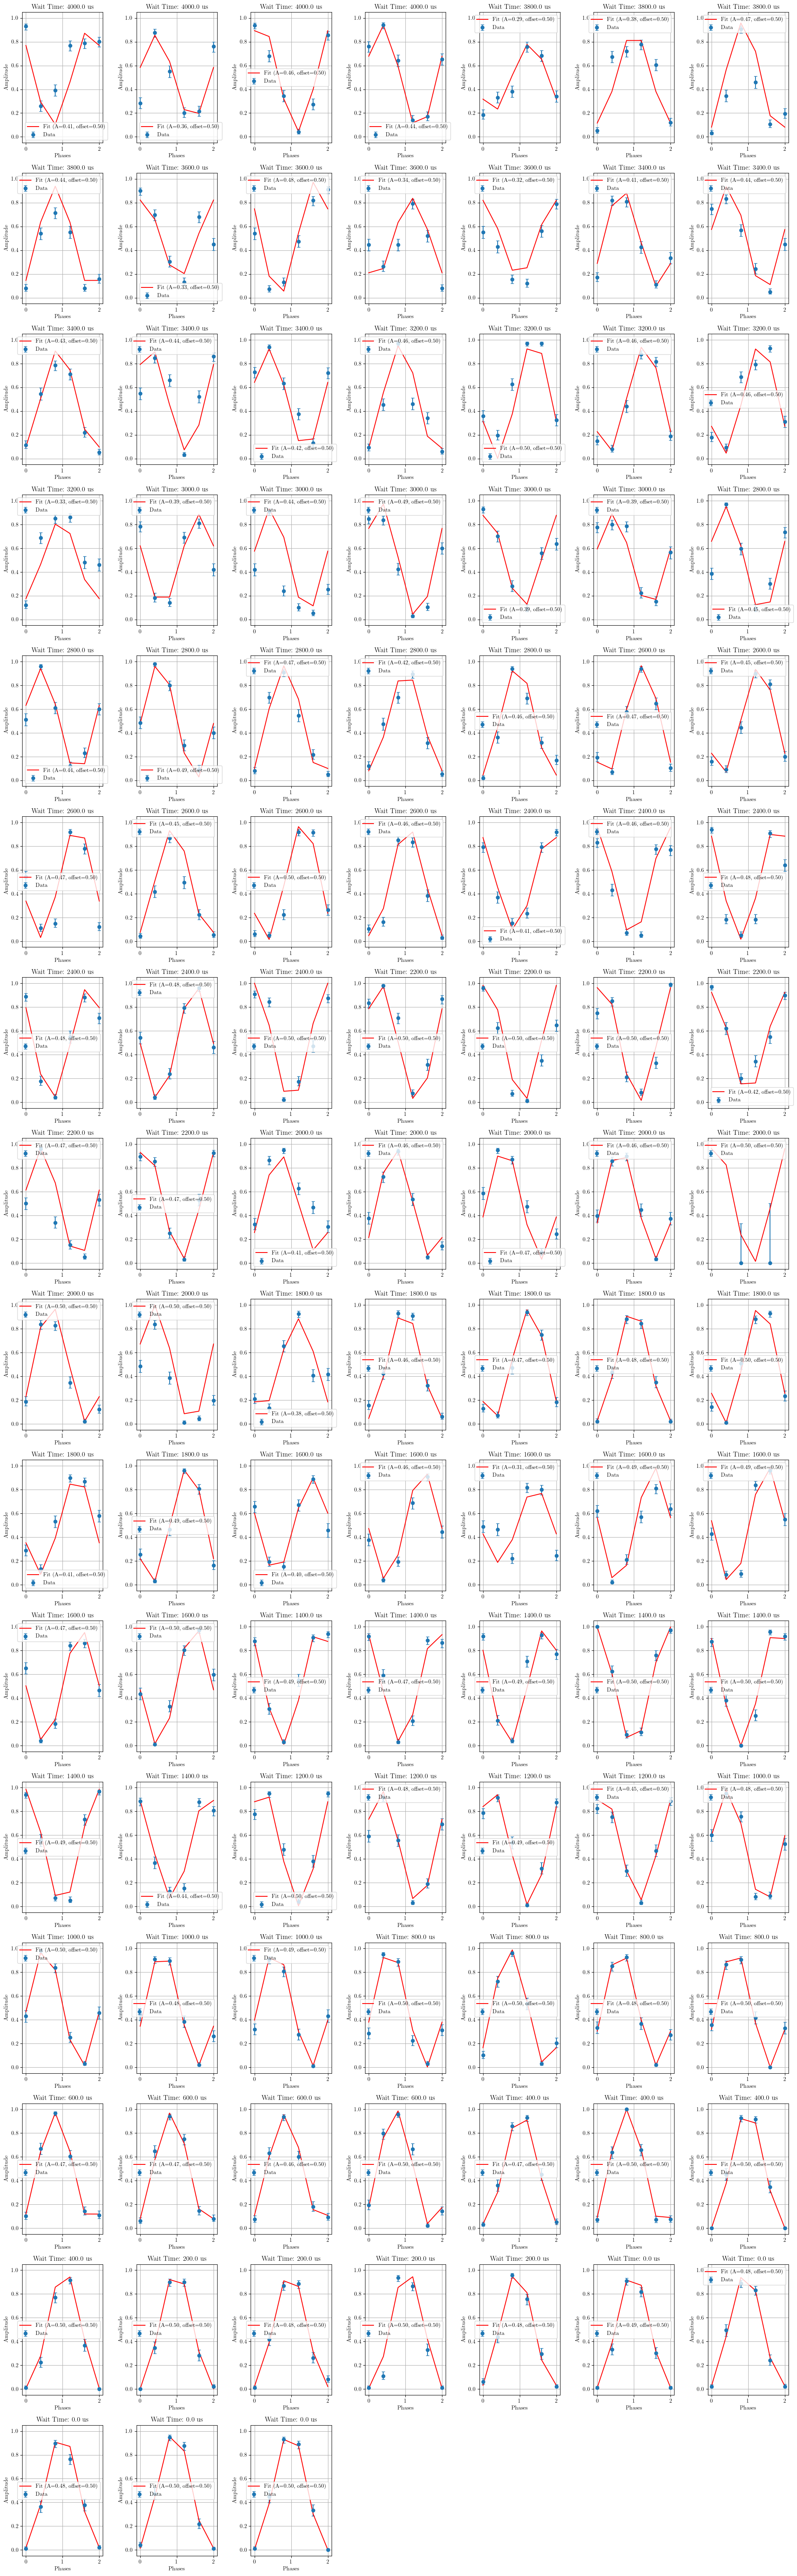

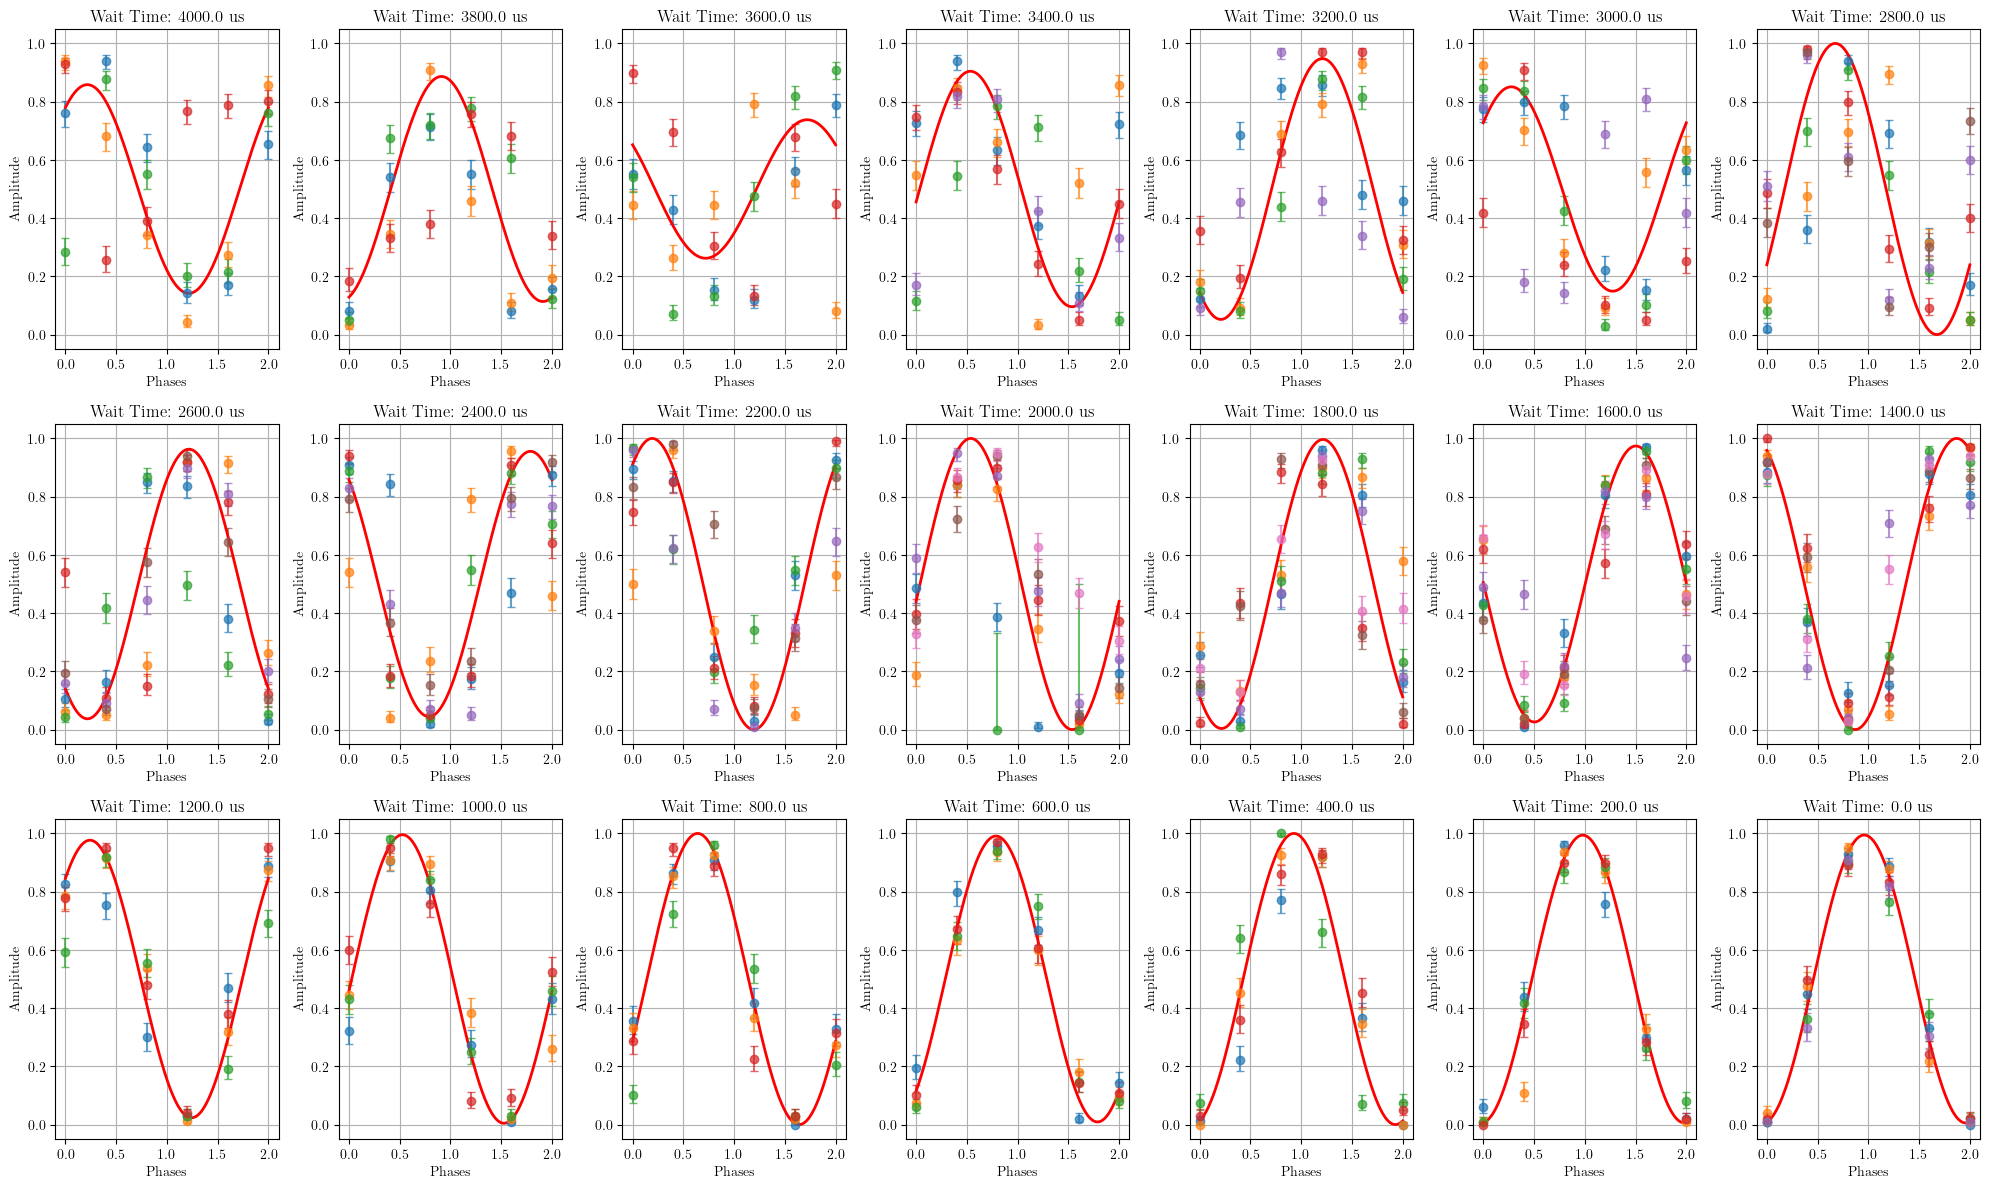

doing ref False
doing best False
Running aggregated analysis for transitions [[0, 3, 2], [0, 2, 0]], LT_comp=True, grouped wait times=21
  wait=0.0 us, paper files=5, raw files=30
  wait=200.0 us, paper files=5, raw files=30
  wait=400.0 us, paper files=5, raw files=30
  wait=600.0 us, paper files=5, raw files=30
  wait=800.0 us, paper files=5, raw files=30
  wait=1000.0 us, paper files=5, raw files=30
  wait=1200.0 us, paper files=5, raw files=30
  wait=1400.0 us, paper files=5, raw files=30
  wait=1600.0 us, paper files=5, raw files=30
  wait=1800.0 us, paper files=4, raw files=24
  wait=2000.0 us, paper files=4, raw files=24
  wait=2200.0 us, paper files=4, raw files=24
  wait=2400.0 us, paper files=4, raw files=24
  wait=2600.0 us, paper files=4, raw files=24
  wait=2800.0 us, paper files=4, raw files=24
  wait=3000.0 us, paper files=4, raw files=24
  wait=3200.0 us, paper files=4, raw files=24
  wait=3400.0 us, paper files=4, raw files=24
  wait=3600.0 us, paper files=4, raw files

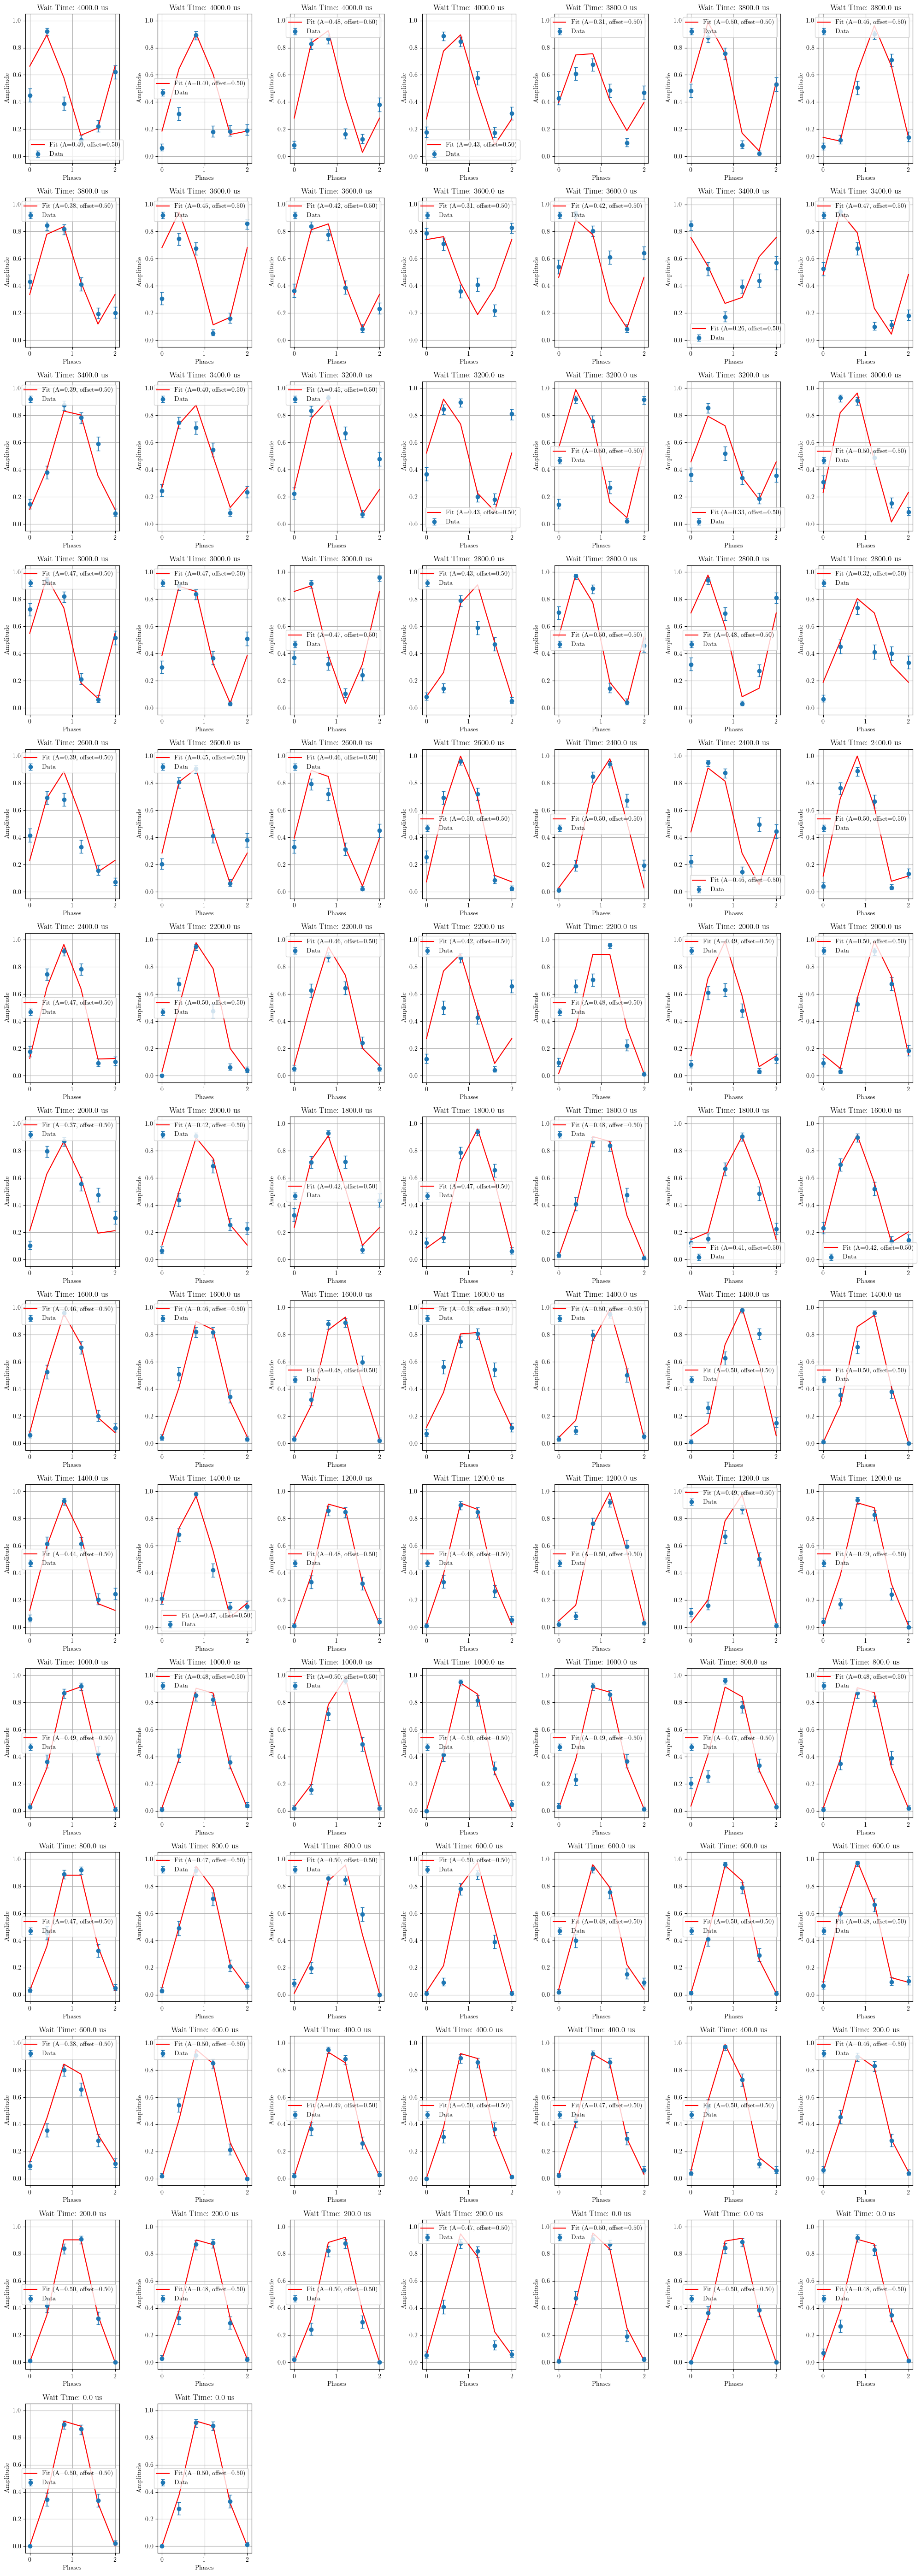

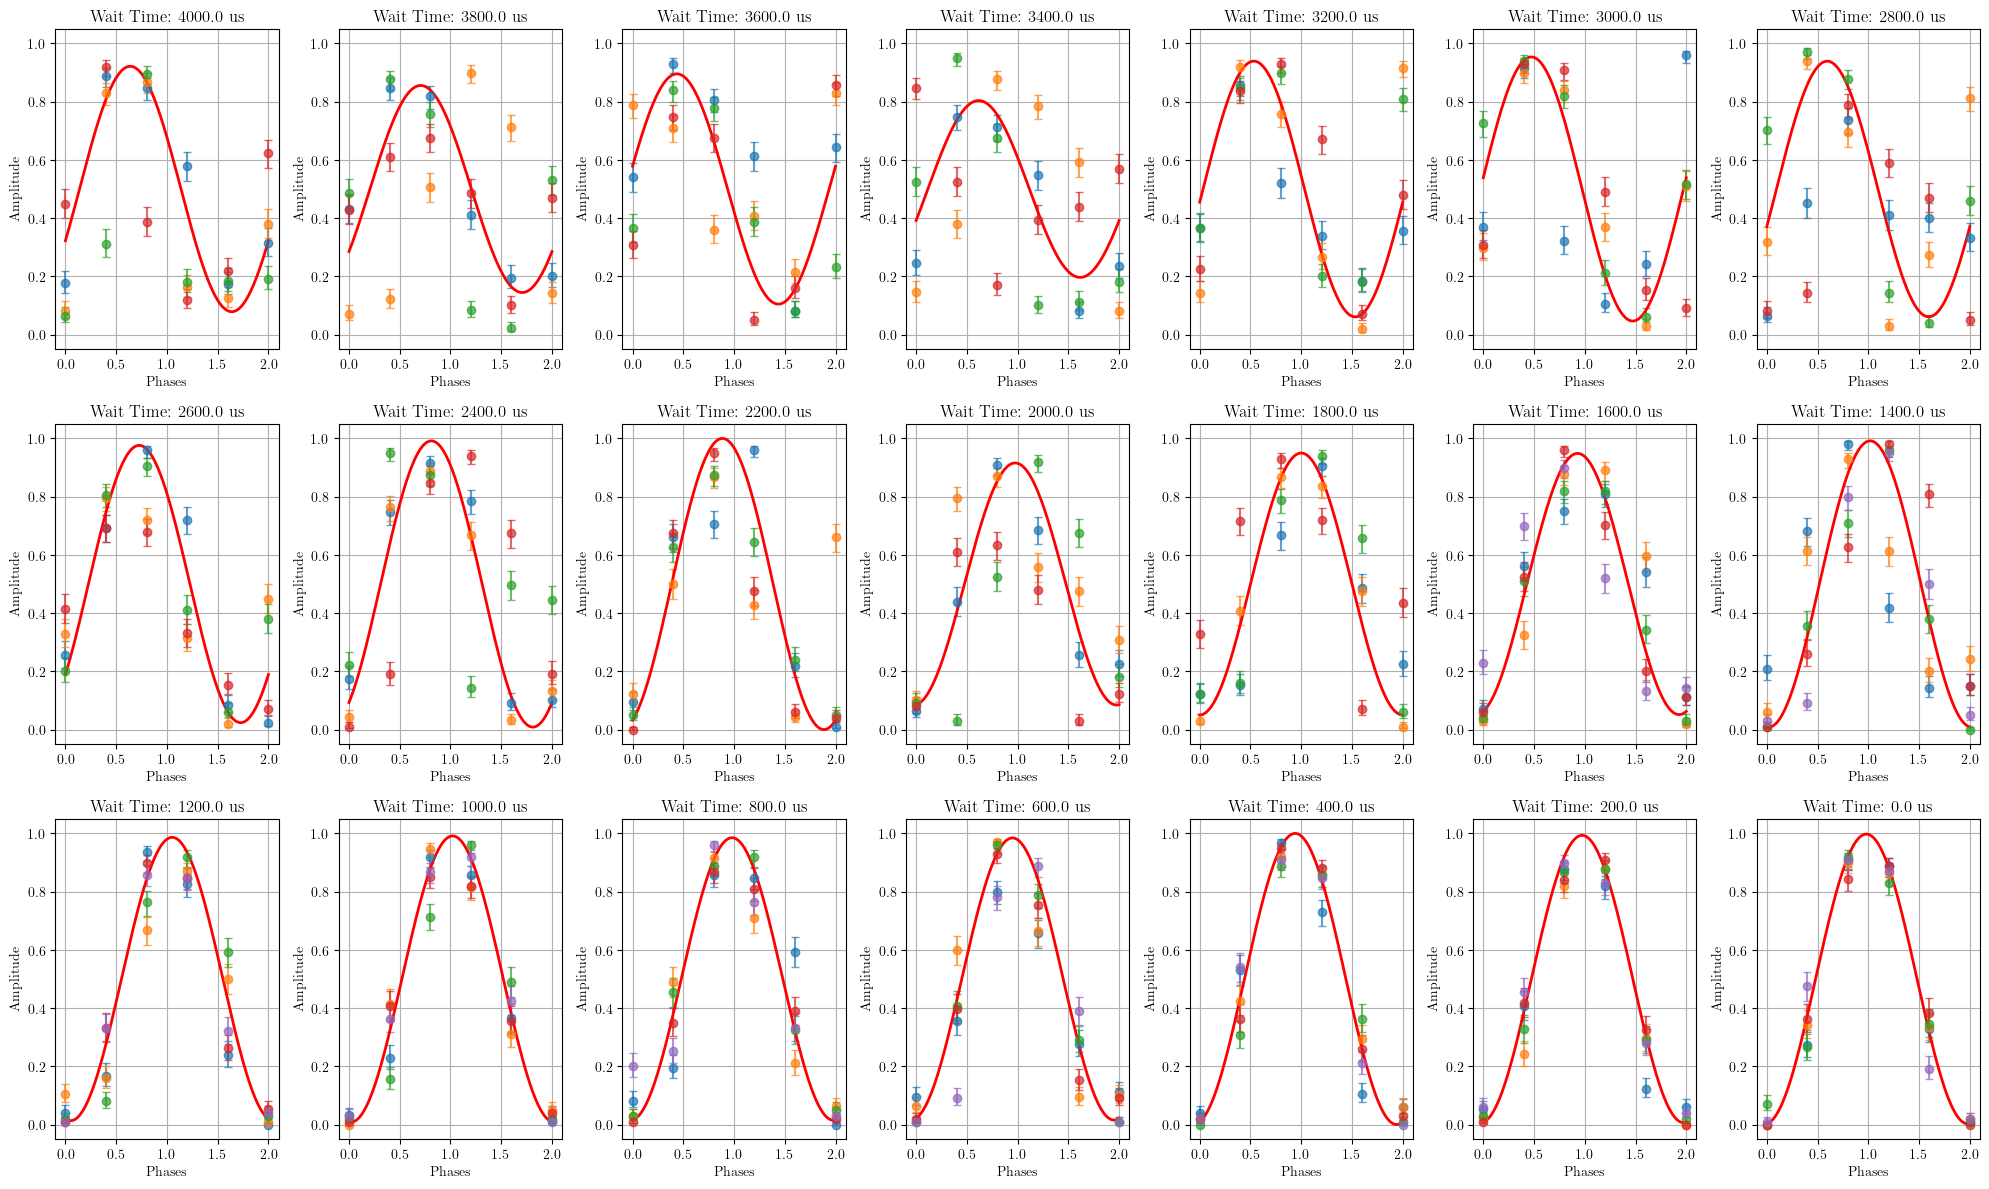

doing ref True
doing best True


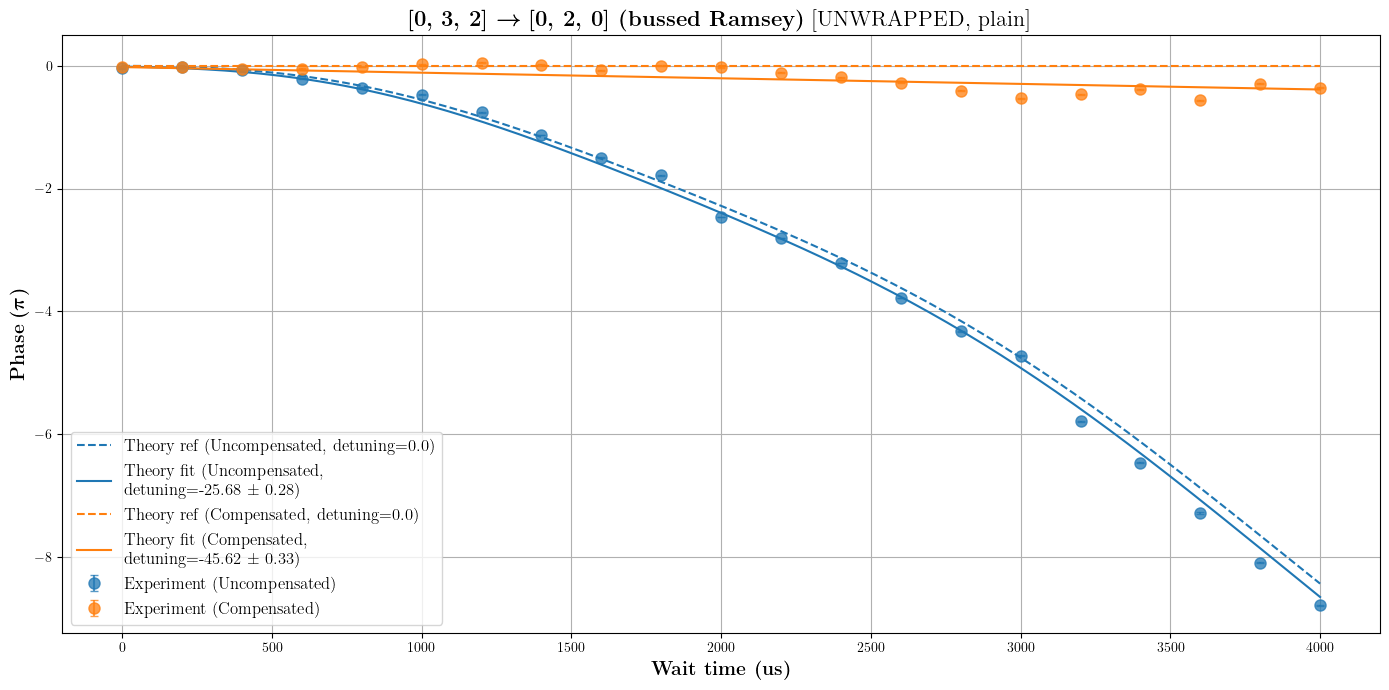

In [69]:
print("Selected transition:", target_transitions)
for lt_mode in [False, True]:
    try:
        wait_times_preview, _, wait_groups_preview = get_grouped_wait_data(
            paper_index, target_transitions, lt_mode
        )
        individual_waits_preview, _, _ = expand_grouped_wait_data_to_individual_scans(wait_groups_preview)
        print(
            f"LT_comp={lt_mode}: {len(wait_times_preview)} grouped wait times, "
            f"{len(individual_waits_preview)} individual paper-data scans, "
            f"first few grouped wait times={wait_times_preview[:10]}"
        )
    except Exception as exc:
        print(f"LT_comp={lt_mode}: {exc}")

payloads, y_data, wait_times = run_full_bussed_ramsey_pipeline_paper(
    paper_index=paper_index,
    target_transitions=target_transitions,
    mean_dev_hz=mean_dev_hz,
    LT_comp_mode="both",
    do_plot=True,
    guided = False,
    do_unwrap=True,
)


## Plot amplitude vs wait time


Uncompensated: A0 = 1.0096 ± 0.0028, T2_G = 7469.65 ± 152.04 us, T2_L = 268262301668.71 ± 0.00 us, T2* = 7469.65 us
Compensated: A0 = 0.9940 ± 0.0025, T2_G = 8053.64 ± 199.99 us, T2_L = 139173674513.40 ± 0.00 us, T2* = 8053.64 us


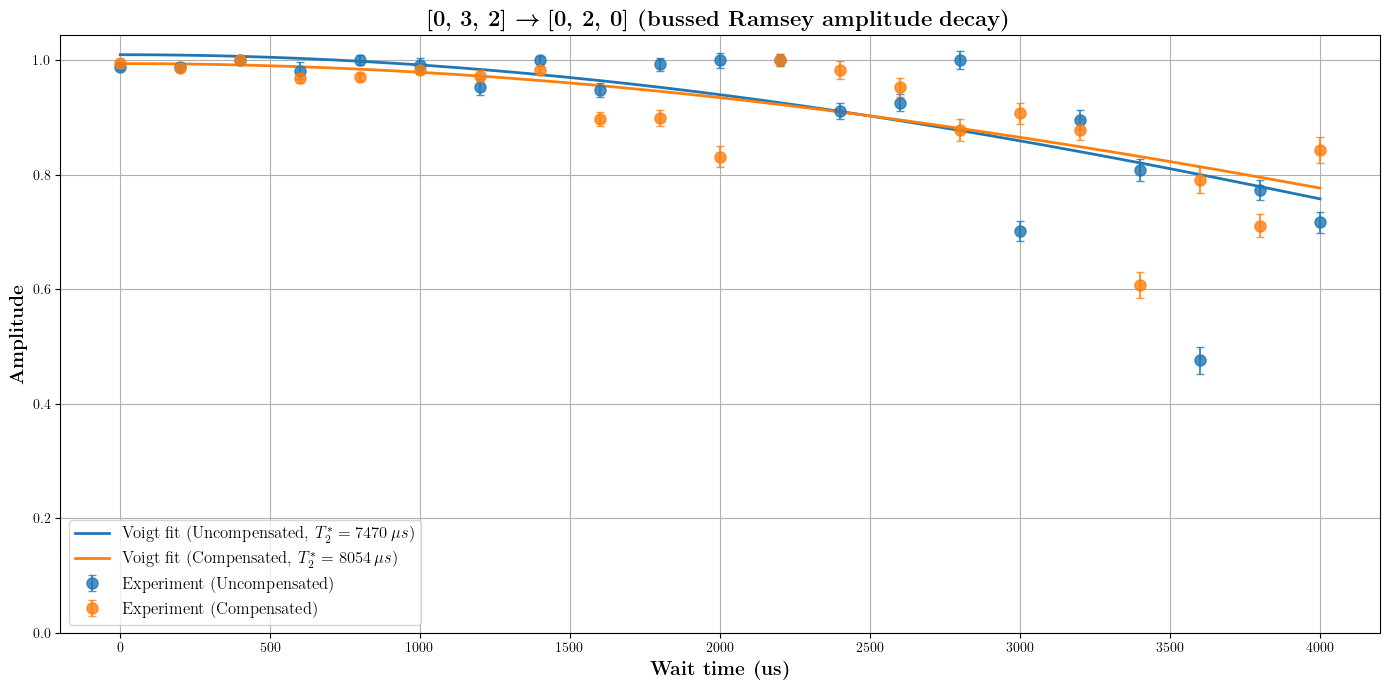

{False: {'wait_times_us': array([   0.,  200.,  400.,  600.,  800., 1000., 1200., 1400., 1600.,
         1800., 2000., 2200., 2400., 2600., 2800., 3000., 3200., 3400.,
         3600., 3800., 4000.]),
  'amplitudes': array([0.98892592, 0.9879711 , 1.        , 0.98192763, 1.        ,
         0.99100742, 0.95338144, 1.        , 0.94790657, 0.9926849 ,
         1.        , 1.        , 0.91132571, 0.92599237, 1.        ,
         0.70191936, 0.89591427, 0.80872138, 0.47575555, 0.77288402,
         0.71668044]),
  'amplitude_errors': array([0.00677124, 0.00703785, 0.00513516, 0.01455494, 0.00848706,
         0.01268923, 0.01355348, 0.00668661, 0.01178673, 0.01128745,
         0.01329546, 0.01085402, 0.01345359, 0.01420269, 0.01582882,
         0.01764566, 0.01676299, 0.01950679, 0.02408798, 0.01780793,
         0.01912901]),
  'params': array([1.00955886e+00, 7.46965170e+03, 2.68262302e+11]),
  'param_errors': array([2.82908788e-03, 1.52036296e+02, 1.33677771e-13]),
  'A0': 1.00955885572849

In [50]:
amplitude_fit_results = plot_bussed_ramsey_amplitudes(
    [payloads[mode] for mode in [False, True] if mode in payloads]
)

amplitude_fit_results
